## **Predicción Temprana del Riesgo Cardiovascular mediante Integración Inteligente de Datos Biométricos y de Hábitos Digitales**

*   Alumno: Alfredo Carreras Gómez
*   Director: Francisco Pascual Romero Chicharro
*   Codirector: José Antonio de la Torre las Herasho
---
*LIBRETA 2*

Esta libreta corresponde a la fase de **Modelado y Evaluación** dentro de la metodología **CRISP-DM**.

Utilizaremos el dataset `df_user_full_procesado.csv`, generado en la **Libreta 1**, donde cada fila representa un usuario y contiene variables biométricas, de estilo de vida, engagement y salud previamente limpias, agregadas y transformadas.

## Objetivos de esta libreta

1. Definir un **pipeline de modelado reproducible**.
2. Seleccionar y preparar las variables adecuadas para clustering.
3. Comparar varios algoritmos de agrupamiento:
   - **K-Means**
   - **Agglomerative Clustering**
   - **Gaussian Mixture Models (GMM)**
   - **HDBSCAN**
   - **K-Medoids**
   
4. Evaluar rigurosamente los modelos con métricas internas:
   - **Silhouette Score**
   - **Davies-Bouldin Index**
   - **Calinski-Harabasz Score**
   - **AIC/BIC** (para modelos probabilísticos GMM)

5. Analizar la **estabilidad** de la solución seleccionada.
6. Interpretar los clusters en términos de **riesgo cardiovascular**, utilidad clínica y aplicación empresarial.

## 1.Librerías y configuración inicial

En este bloque se importan las librerías necesarias y se define una configuración base para garantizar reproducibilidad.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier

#Modelos de Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

#Métricas de Evaluación
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

HDBSCAN_AVAILABLE = False
KMEDOIDS_AVAILABLE = False

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    pass

try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
except Exception:
    print("KMedoids no carga bien")
    pass

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

print("KMedoids disponible:", KMEDOIDS_AVAILABLE)
print("HDBSCAN disponible:", HDBSCAN_AVAILABLE)

KMedoids no carga bien
KMedoids disponible: False
HDBSCAN disponible: True


Al ser una fase experimental, deseamos probar con distintos algortimos: **K-Means, Agglomerative Clustering, Gaussian Mixture Models (GMM), HDBSCAN y K-Medoids**

## 2.Carga del dataset final generado en la Libreta 1

Cargamos y leemos el CSV `df_user_full_procesado.csv` y vamos a realizar unos cuantos ajustes:

* Indexación: Vamos a establecer el `userID` como índice con el objetivo de evitar que actué como una característica y afecte en el cáclulo de distancias.

* Codificación binaria: La variable `gender` la pasamos a un formato booleano para así facilitar su posterior procesamiento

Comprobamos el Shape del dataset: (4668 usuarios, 38 columnas)

In [ ]:
DATA_PATH = Path("df_user_full_procesado.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra el archivo {DATA_PATH.resolve()}\n"
        "Coloca el CSV en la misma carpeta que esta libreta o ajusta DATA_PATH."
    )

df = pd.read_csv((DATA_PATH), sep=';', decimal=',', encoding='utf-8-sig')

if 'userID' in df.columns:
    df = df.set_index('userID')

if "gender" in df.columns:
    df['gender'] = df['gender'].map({'male': 1, 'female': 0})

print("Shape del dataset:", df.shape)
display(df.head())

Shape del dataset: (4668, 38)


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,contentID,device,diet,dislikeRecipes,emotionalGoalsAchieved,fitnessAvailabilityDays,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,likeRecipes,nutritionalCategory,site,sleepGoal,stepsGoal,waistCirc,weight_clean,cardiovascularRecipeID,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0.0,0,0,37,NaN,intense,overweight,27.78,2.0,52085.0,NaN,NaN,1.0,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",3163.22,1.0,0.0,1,1.79,NaN,NaN,1,480,10000,60.0,89.0,NaN,0,0,0,0,0,0,0,0
3,0,0.0,11,11,39,NaN,moderate,overweight,25.03,7.0,50788.0,"3,5,6,1,4",APPLE_WATCH,2.0,Tostada de pan de molde integral,0.0,"MONDAY, TUESDAY, WEDNESDAY, THURSDAY",2737.69,1.0,14355.0,1,1.81,Tosta de aguacate y tomate,NaN,1,480,10000,79.0,82.0,NaN,0,0,0,0,0,0,0,0
35,0,0.0,0,0,45,NaN,moderate,overweight,25.13,5.0,NaN,NaN,WELLAT_CAVOSMART,NaN,NaN,NaN,"MONDAY, TUESDAY, WEDNESDAY, FRIDAY, SATURDAY, ...",NaN,1.0,0.0,1,1.85,NaN,NaN,1,480,10000,97.0,86.0,NaN,0,0,0,0,0,0,0,0
50,0,23.0,0,2,45,NaN,moderate,normal_weight,24.09,6.0,50788.0,NaN,APPLE_WATCH,25.0,NaN,0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2019.26,1.0,7030.0,0,1.63,NaN,NaN,1,420,10000,60.0,64.0,NaN,0,0,0,0,0,0,0,0
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,"7,6,4,1",APPLE_WATCH,25.0,"Papas aliñadas, Tostada de queso manchego, Caf...",0.0,"MONDAY, WEDNESDAY, THURSDAY, SATURDAY",2234.38,2.0,100045.0,1,1.80,"Torta de arroz inflado integral, Plátano, Nara...",NaN,1,480,8500,87.0,72.0,NaN,0,0,0,0,0,0,0,1


## 3.Revisión inicial del dataset de modelado

Antes de entrenar modelos, verificamos la estructura, nulos, columnas constantes e identificadores.

In [ ]:
print("\nTipos de datos:")
display(df.dtypes.value_counts())

print("\nPorcentaje de nulos por columna (top 30):")
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(null_pct.head(30).to_frame("null_pct"))


Tipos de datos:


,count
int64,16
float64,12
object,10



Porcentaje de nulos por columna (top 30):


,null_pct
nutritionalCategory,99.935733
cardiovascularRecipeID,99.935733
contentID,99.121680
dislikeRecipes,92.373608
likeRecipes,86.225364
allergies,81.319623
device,50.814053
emotionalGoalsAchieved,37.103685
foodEnergyExpenditure,17.459297
diet,17.459297


## 4.Identificación y exclusión de columnas no aptas para clustering

Para garantizar la convergencia de los algoritmos de clustering y así evitar ruido al calcular distancias, vamos a hacer una criba de variables por los siguientes motivos:

* Identificadores y metadatos: Variables como `contentId` o `cardiovascularRecipeID` (son identificadores únicos o referencias a contenidos que no describen el perfil biométrico del usuario).
*   texto libre con longitud media de texto >25
*   fechas sin transformar

In [ ]:
text_like_cols = []
for c in df.columns:
    if df[c].dtype == "object":
        avg_len = df[c].dropna().astype(str).str.len().mean() if df[c].notna().sum() > 0 else 0
        if avg_len and avg_len > 25:
            text_like_cols.append(c)

exclude_cols = sorted(set(text_like_cols))

print("Columnas excluidas:")
display(exclude_cols)

Columnas excluidas:


['dislikeRecipes',
 'fitnessAvailabilityDays',
 'likeRecipes',
 'nutritionalCategory']

Incluiremos ademas estas otras columnas identificadas para su exclusión: `dislikeRecipes`, `fitnessAvailabilityDays`,  `likeRecipes`,  `nutritionalCategory`.



In [ ]:
force_drop = ['dislikeRecipes', 'fitnessAvailabilityDays', 'likeRecipes', 'nutritionalCategory', 'cardiovascularRecipeID', 'contentID']
df = df.drop(columns=[c for c in force_drop if c in df.columns])

# DATASET BASE PARA MODELADO
df_model = df.copy()

print("Shape de df_model:", df_model.shape)
display(df_model.head())

Shape de df_model: (4668, 32)


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,allergies,avgExerciseIntensity,bmiType,bmi_clean,bodyFat,contentConsumptionMinutes,device,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
userID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,0.0,0,0,37,NaN,intense,overweight,27.78,2.0,52085.0,NaN,1.0,NaN,3163.22,1.0,0.0,1,1.79,1,480,10000,60.0,89.0,0,0,0,0,0,0,0,0
3,0,0.0,11,11,39,NaN,moderate,overweight,25.03,7.0,50788.0,APPLE_WATCH,2.0,0.0,2737.69,1.0,14355.0,1,1.81,1,480,10000,79.0,82.0,0,0,0,0,0,0,0,0
35,0,0.0,0,0,45,NaN,moderate,overweight,25.13,5.0,NaN,WELLAT_CAVOSMART,NaN,NaN,NaN,1.0,0.0,1,1.85,1,480,10000,97.0,86.0,0,0,0,0,0,0,0,0
50,0,23.0,0,2,45,NaN,moderate,normal_weight,24.09,6.0,50788.0,APPLE_WATCH,25.0,0.0,2019.26,1.0,7030.0,0,1.63,1,420,10000,60.0,64.0,0,0,0,0,0,0,0,0
92,0,112176.0,5,100,45,NaN,light,normal_weight,22.22,4.0,50788.0,APPLE_WATCH,25.0,0.0,2234.38,2.0,100045.0,1,1.80,1,480,8500,87.0,72.0,0,0,0,0,0,0,0,1


## 5.Selección de variables para modelado

A continuación realizaremos la selección final de variables para clustering.

Se separan variables en:
- **Continuas**:  pueden tomar cualquier valor numérico dentro de un rango
- **Binarias**: solo pueden tomar dos valores (ej: 0 o 1)
- **Categóricas**: representan categorías o grupos, no números con significado matemático

In [ ]:

object_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_all = df_model.select_dtypes(include=[np.number, "bool"]).columns.tolist()

binary_cols = []
continuous_cols = []

for c in numeric_all:
    vals = pd.Series(df_model[c].dropna().unique())
    if len(vals) <= 2 and set(vals.tolist()).issubset({0, 1, True, False}):
        binary_cols.append(c)
    else:
        continuous_cols.append(c)

categorical_cols = object_cols.copy()

print("Variables continuas:", len(continuous_cols))
display(continuous_cols)

print("Variables binarias:", len(binary_cols))
display(binary_cols)

print("Variables categóricas:", len(categorical_cols))
display(categorical_cols)

Variables continuas: 21


['emotionalWorkshopEnrollments',
 'mindfulnessTime',
 'nutritionWorkshopEnrollments',
 'physicalActivitySesions',
 'age',
 'bmi_clean',
 'bodyFat',
 'contentConsumptionMinutes',
 'diet',
 'emotionalGoalsAchieved',
 'foodEnergyExpenditure',
 'gamificationLevels',
 'gamificationPoints',
 'height_clean',
 'site',
 'sleepGoal',
 'stepsGoal',
 'waistCirc',
 'weight_clean',
 'Num_HealthProblems',
 'Num_Allergies']

Variables binarias: 7


['gender',
 'Has_Diabetes',
 'Has_Colesterol',
 'Has_Tension',
 'Has_Hierro',
 'Has_Calcio',
 'Has_Mindfulness']

Variables categóricas: 4


['allergies', 'avgExerciseIntensity', 'bmiType', 'device']

<Figure size 1000x500 with 0 Axes>

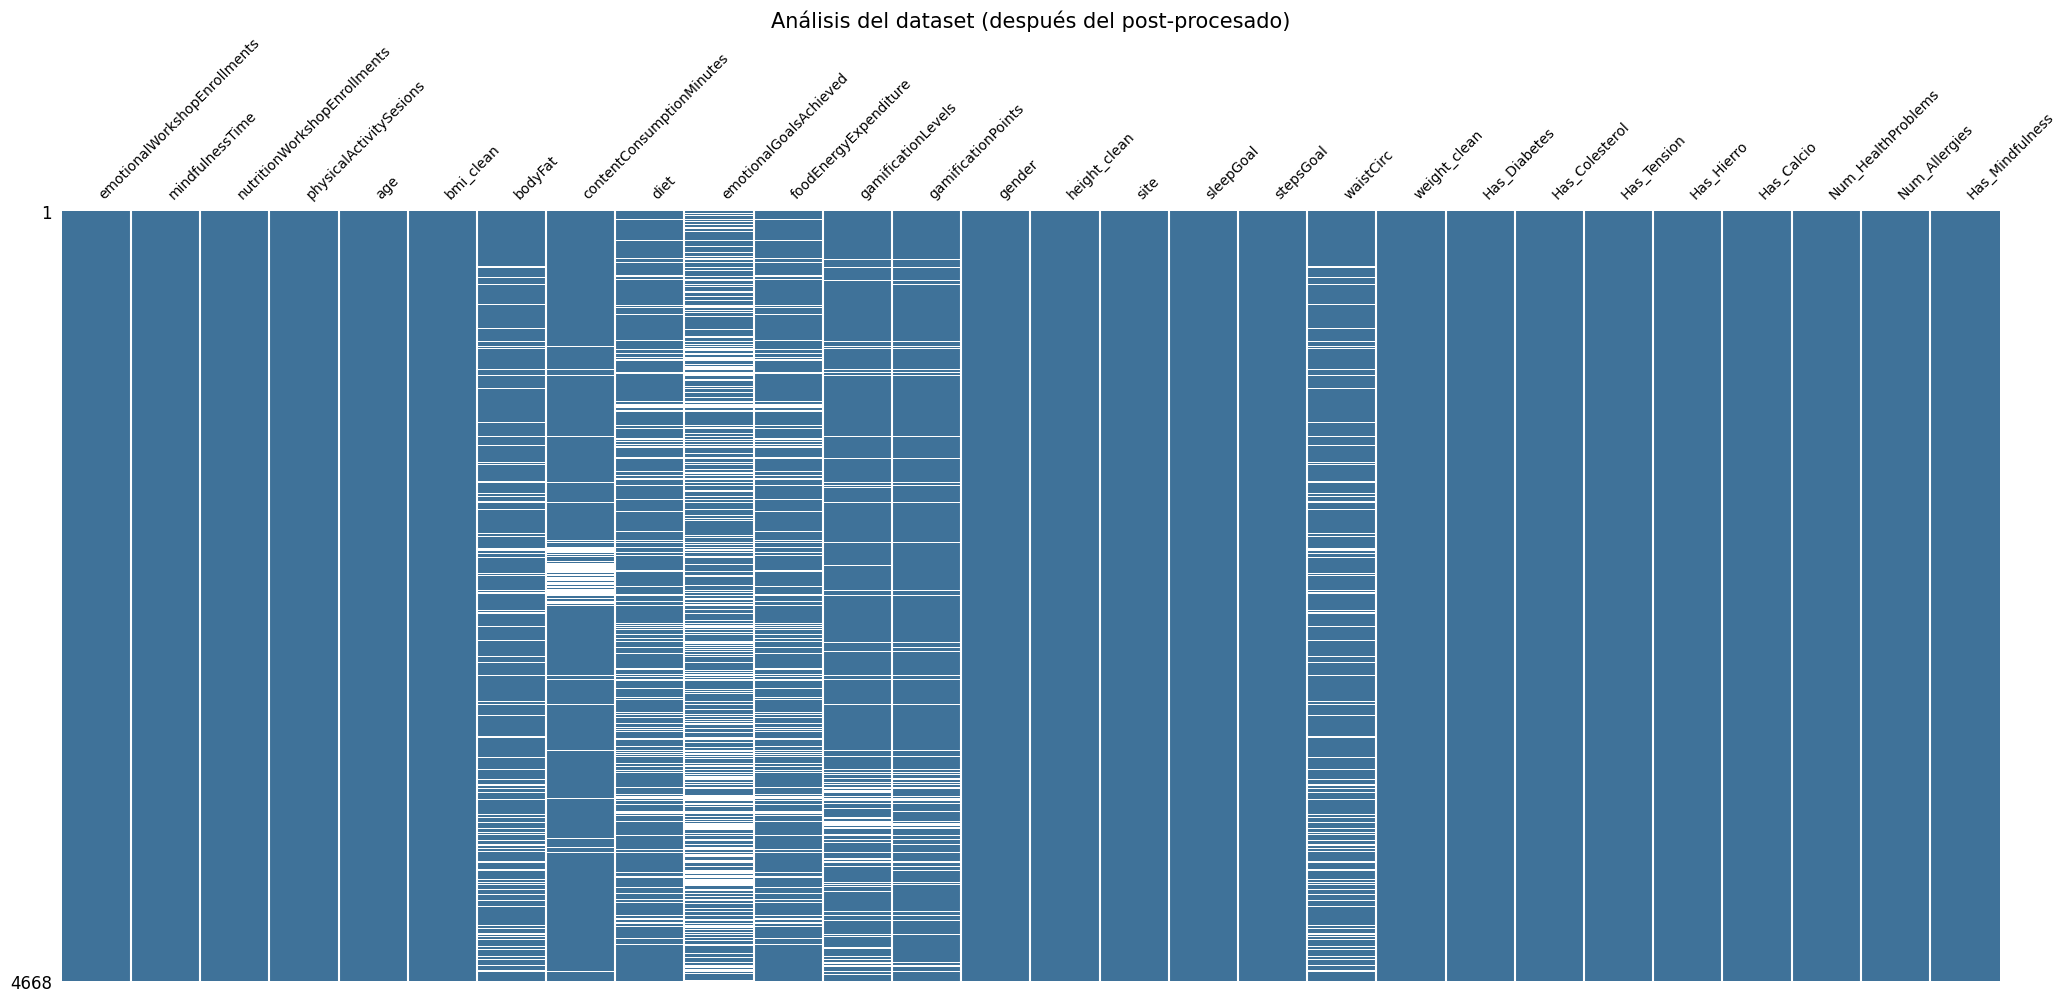

In [ ]:
df_numericas = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 5))
msno.matrix(df_numericas, sparkline=False, fontsize=10, color=(0.25, 0.45, 0.6))
plt.title("Análisis del dataset (después del post-procesado)", fontsize=15)
plt.show()

### 5.1 Revisión manual de variables
Se observa y se corrige que:

*    `diet` la trata como numérica, pero debería ser categórica ya que contiene la categoria / tipo de dieta seleccionada por el usuario.
*   `bodyFat` la trata como numérica, pero debería ser categórica ya que contiene la categoria correspondiente al grupo de % de grasa.

In [ ]:
move_to_binary = []
move_to_categorical = ['diet', 'bodyFat']

for c in move_to_binary:
    if c in continuous_cols:
        continuous_cols.remove(c)
    if c in categorical_cols:
        categorical_cols.remove(c)
    if c in df_model.columns and c not in binary_cols:
        binary_cols.append(c)

for c in move_to_categorical:
    if c in continuous_cols:
        continuous_cols.remove(c)
    if c in binary_cols:
        binary_cols.remove(c)
    if c in df_model.columns and c not in categorical_cols:
        categorical_cols.append(c)

print("Resumen final de variables:")
print("Continuas:", len(continuous_cols))
print("Binarias:", len(binary_cols))
print("Categóricas:", len(categorical_cols))

Resumen final de variables:
Continuas: 19
Binarias: 7
Categóricas: 6


## 6.Pipeline de preprocesamiento para clustering
Vamos a construir el pipeline de preprocesamiento final que transforma el dataset en una matriz numérica lista para aplicar los algoritmos de clustering.

Dependiente el tipo de variable, para valores faltantes imputaremos:
- **Continuas** → `KNNImputer` + `StandardScaler` (en base a similitud entre usuarios y estandarizamos)
- **Binarias** → `SimpleImputer(strategy="most_frequent")` imputamos los valores ausentes con la categoria más frecuente.
- **Categóricas** → `SimpleImputer(strategy="most_frequent")` + `OneHotEncoder` imputamos los faltantes con la moda y los transformamos convirtiéndolas en variables numéricas.

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, continuous_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

X = preprocessor.fit_transform(df_model)

print("Shape de la matriz final para clustering:", X.shape)
print("Tipo de X:", type(X))

Shape de la matriz final para clustering: (4668, 452)
Tipo de X: <class 'numpy.ndarray'>


### 6.1 Recuperación de nombres de variables transformadas

Comprobamos valores y nombre de las columnas tras la transformación.

In [ ]:
feature_names = preprocessor.get_feature_names_out()
feature_names = [f.replace("num__", "").replace("bin__", "").replace("cat__", "") for f in feature_names]

X_df = pd.DataFrame(X, columns=feature_names, index=df_model.index)

print("Shape de X_df:", X_df.shape)
display(X_df.head())

Shape de X_df: (4668, 452)


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,bmi_clean,contentConsumptionMinutes,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Num_HealthProblems,Num_Allergies,gender,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Has_Mindfulness,allergies_1,"allergies_1, 1","allergies_1, 10, 13, 14","allergies_1, 2","allergies_1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13","allergies_1, 2, 3, 4, 5, 6, 8, 9, 11, 12","allergies_1, 2, 3, 4, 5, 7, 8, 10, 11, 12","allergies_1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 11","allergies_1, 2, 3, 4, 6, 7, 8, 9, 12, 13","allergies_1, 2, 3, 4, 7","allergies_1, 2, 3, 4, 7, 9, 11","allergies_1, 2, 3, 4, 7, 9, 12","allergies_1, 2, 3, 5, 7, 8","allergies_1, 2, 4, 12, 13, 14","allergies_1, 3","allergies_1, 3, 2, 4, 5, 7, 8, 10, 12, 13, 14","allergies_1, 3, 4","allergies_1, 3, 4, 5, 12","allergies_1, 3, 4, 5, 6, 2, 8, 7, 9, 12","allergies_1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13","allergies_1, 3, 4, 5, 7, 8, 9, 11, 1, 3, 5, 7, 9","allergies_1, 3, 4, 6, 7, 14","allergies_1, 3, 4, 6, 7, 5, 8, 10, 9, 12, 13, 11","allergies_1, 3, 4, 7","allergies_1, 3, 4, 7, 2, 6, 9, 10, 12, 13, 14","allergies_1, 3, 4, 7, 8","allergies_1, 3, 5, 11, 4","allergies_1, 3, 5, 7","allergies_1, 3, 5, 7, 8","allergies_1, 3, 7","allergies_1, 3, 7, 8, 10, 11, 13, 14","allergies_1, 4","allergies_1, 4, 3, 6, 11","allergies_1, 4, 3, 8, 7, 10, 11, 2","allergies_1, 4, 5","allergies_1, 5, 3, 7","allergies_1, 5, 6","allergies_1, 5, 6, 7, 10, 13, 14","allergies_1, 5, 6, 7, 14","allergies_1, 5, 6, 8, 11","allergies_1, 6","allergies_1, 6, 5, 7","allergies_1, 6, 7","allergies_1, 7","allergies_1, 7, 1, 7","allergies_1, 7, 11","allergies_1, 7, 12","allergies_1, 7, 12, 2, 4, 13","allergies_1, 7, 14","allergies_1, 7, 14, 1, 7, 14","allergies_1, 7, 5, 14","allergies_1, 8",allergies_1.0,allergies_10,"allergies_10, 10","allergies_10, 11","allergies_10, 14","allergies_10, 9, 12","allergies_10, 9, 8, 5",allergies_11,allergies_12,"allergies_12, 12","allergies_12, 13","allergies_12, 13, 2","allergies_12, 13, 8, 6, 7, 4, 3, 2","allergies_12, 2","allergies_12, 2, 10",allergies_13,"allergies_13, 10","allergies_13, 14, 13",allergies_14,"allergies_14, 14","allergies_14, 9, 1",allergies_2,...,"allergies_4, 7, 8","allergies_4, 8","allergies_4, 8, 6","allergies_4, 8, 7, 3","allergies_4, 9",allergies_5,"allergies_5, 1, 10","allergies_5, 1, 4, 12, 13, 8, 6, 2, 7, 10, 9, 14, 11","allergies_5, 10","allergies_5, 3, 4, 1, 6, 12","allergies_5, 3, 4, 7, 11","allergies_5, 4, 7, 10, 12, 3","allergies_5, 5","allergies_5, 5, 8","allergies_5, 6, 14","allergies_5, 6, 7, 8","allergies_5, 6, 8, 9, 10, 11, 13","allergies_5, 8","allergies_5, 8, 10","allergies_5, 8, 11","allergies_5, 8, 13","allergies_5, 9, 13, 14",allergies_6,"allergies_6, 13, 14","allergies_6, 2","allergies_6, 8","allergies_6, 8, 9, 10","allergies_6, 9","allergies_6, 9, 3, 4",allergies_7,"allergies_7, 1, 7","allergies_7, 10","allergies_7, 10, 13","allergies_7, 11","allergies_7, 12","allergies_7, 13","allergies_7, 14","allergies_7, 3","allergies_7, 3, 14","allergies_7, 3, 8","allergies_7, 4","allergies_7, 4, 2, 13, 12, 9","allergies_7, 4, 3, 2, 12","allergies_7, 5, 3, 1, 4, 8","allergies_7, 5, 3, 4, 2","allergies_7, 6, 13","allergies_7, 7","allergies_7, 7, 7","allergies_7, 8","allergies_7, 8, 12, 11, 14, 13, 6, 5, 3, 4, 2, 1","allergies_7, 8, 5, 6, 4, 3","allergies_7, 9, 10, 13","allergies_7, 9, 14",allergies_7.0,allergies_8,"allergies_8, 13","allergies_8, 13, 5","allergies_8, 4, 3",allergies_9,"allergies_9, 10","allergies_9, 12, 13","allergies_9, 13","allergies_9, 13, 9, 13","allergies_9, 14",allergies_9.0,avgExerciseIntensity_intense,avgExerciseIntensity_light,avgExerciseIntensity_moderate,avgExerciseIntensity_sedentary,avgExerciseIntensity_very_intense,bmiType_morbid_obesity,bmiType_normal_weight,bmiType_obesity,bmiType_overweight,bmiType_underweight,device_APPLE_WATCH,device

## 7.PCA para visualización exploratoria

Aplicaremos PCA para reducción de dimensionalidad y visualizamos la estructura del dataset antes del clustering. Proyectamos los datos en 2 dimensiones (PC1 y PC2) y se calcula la varianza explicada por cada componente y su acumulado, para evaluar cuánta información del dataset original se conserva.

Varianza explicada por PC1 y PC2: [0.13909735 0.09657904]
Varianza explicada acumulada: 0.2356763915404571


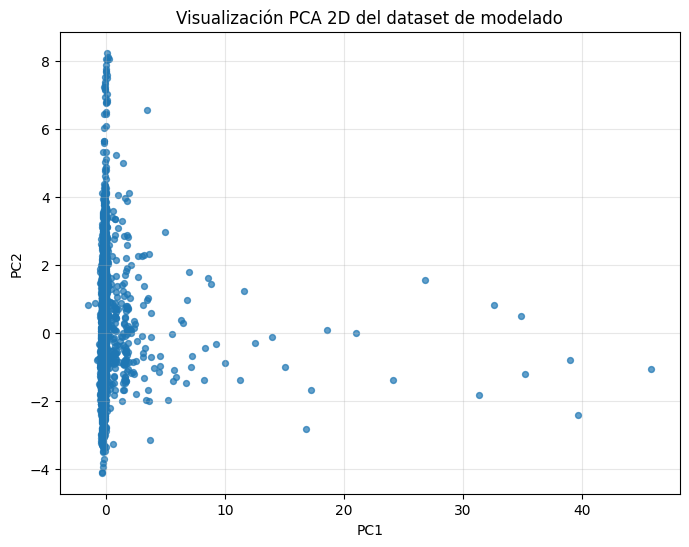

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X)

explained_var = pca_2d.explained_variance_ratio_
print("Varianza explicada por PC1 y PC2:", explained_var)
print("Varianza explicada acumulada:", explained_var.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=18, alpha=0.7)
plt.title("Visualización PCA 2D del dataset de modelado")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

A diferencia de una reducción arbitraria a 2 dimensiones, evaluamos la Varianza Explicada Acumulada para asegurar que el espacio reducido conserve al menos el $90\%$ de la señal original. Con esto podemos garantizar que la segmentación posterior se base en diferencias reales y no en ruido estadístico.

Primeras componentes del PCA:


,Componente,Varianza_Explicada,Varianza_Acumulada
0,1,0.139097,0.139097
1,2,0.096579,0.235676
2,3,0.076724,0.312400
3,4,0.059748,0.372148
4,5,0.055379,0.427528
5,6,0.053873,0.481401
6,7,0.045550,0.526951
7,8,0.044813,0.571764
8,9,0.043569,0.615333
9,10,0.040711,0.656044


Número de componentes necesarios para alcanzar el 90% de varianza: 22
Varianza acumulada retenida con 22 componentes: 0.9016

Comparativa de umbrales:
80% de varianza -> 15 componentes
90% de varianza -> 22 componentes
95% de varianza -> 30 componentes


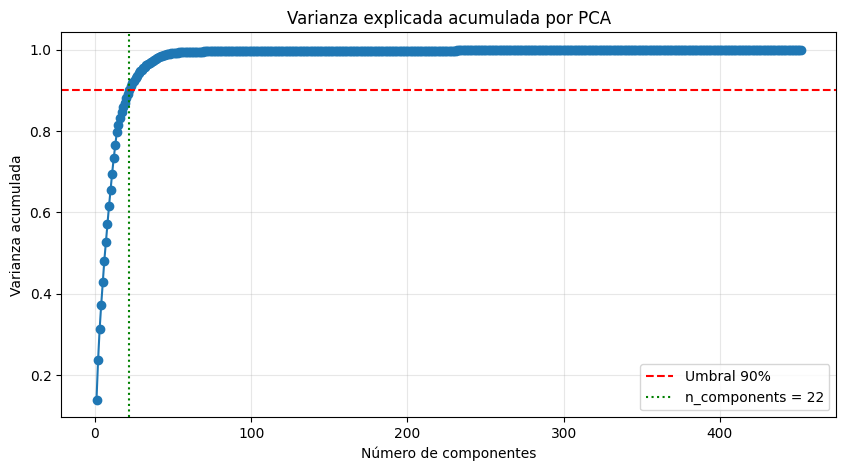

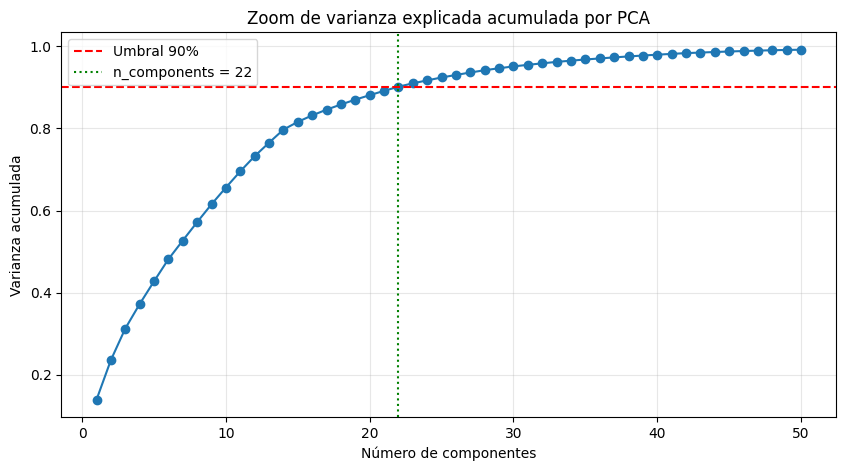

In [ ]:
seed = RANDOM_STATE
umbral_varianza = 0.90

pca_test = PCA(random_state=seed)
pca_test.fit(X)

varianza_explicada = pca_test.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

n_opt = np.argmax(varianza_acumulada >= umbral_varianza) + 1

df_pca_varianza = pd.DataFrame({
    "Componente": np.arange(1, len(varianza_explicada) + 1),
    "Varianza_Explicada": varianza_explicada,
    "Varianza_Acumulada": varianza_acumulada
})

print("Primeras componentes del PCA:")
display(df_pca_varianza.head(25))

print(f"Número de componentes necesarios para alcanzar el {int(umbral_varianza*100)}% de varianza: {n_opt}")
print(f"Varianza acumulada retenida con {n_opt} componentes: {varianza_acumulada[n_opt - 1]:.4f}")

print("\nComparativa de umbrales:")
for umbral in [0.80, 0.90, 0.95]:
    n_comp = np.argmax(varianza_acumulada >= umbral) + 1
    print(f"{int(umbral*100)}% de varianza -> {n_comp} componentes")

# Gráfico global
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=umbral_varianza, color='red', linestyle='--', label=f'Umbral {int(umbral_varianza*100)}%')
plt.axvline(x=n_opt, color='green', linestyle=':', label=f'n_components = {n_opt}')
plt.title('Varianza explicada acumulada por PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Zoom en las primeras componentes
plt.figure(figsize=(10, 5))
max_plot = min(50, len(varianza_acumulada))
plt.plot(range(1, max_plot + 1), varianza_acumulada[:max_plot], marker='o')
plt.axhline(y=umbral_varianza, color='red', linestyle='--', label=f'Umbral {int(umbral_varianza*100)}%')
plt.axvline(x=n_opt, color='green', linestyle=':', label=f'n_components = {n_opt}')
plt.title('Zoom de varianza explicada acumulada por PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

El análisis de varianza explicada acumulada muestra que las primeras componentes principales concentran una proporción elevada de la información total del dataset transformado. **Se requieren 22 componentes para retener aproximadamente el 90.16% de la varianza**.

Pese a la alta dimensionalidad generada tras el preprocesamiento y la codificación de variables categóricas, existe redundancia estructural entre variables y es posible representar el espacio de datos en una dimensión considerablemente menor sin pérdida severa de información.

Por tanto, El PCA se considera una estrategia válida para reducir dimensionalidad y facilitar el proceso de segmentación no supervisada.

Se ha utilizado PCA como técnica principal de reducción de dimensionalidad por su interpretabilidad, estabilidad y eficiencia computacional. PCA asume relaciones lineales entre variables, lo que puede limitar su capacidad para capturar estructuras complejas en datos de salud.

No obstante, se valoraron alternativas como t-SNE o UMAP, que podrían capturar relaciones no lineales, aunque se descartaron en esta fase por su menor interpretabilidad y dificultad para integrarse en un pipeline reproducible de clustering.

## 8.Búsqueda del K óptimo y Comparativa de Modelos

Para identificar la segmentación de riesgo cardiovascular más robusta, se realiza un análisis comparativo tanto del número óptimo de grupos ($K$) como de la naturaleza del modelo de clustering empleado. Con este objetivo, se evalúan tres enfoques complementarios, cada uno con diferentes supuestos sobre la estructura de los datos:

*   **K-Means**: algoritmo basado en centroides que busca particiones compactas
minimizando la varianza intra-cluster. Resulta adecuado para detectar grupos bien definidos en espacios métricos, aunque puede ser sensible a la presencia de outliers y a la forma de los clusters.

*   **Clustering jerárquico aglomerativo** ***(Agglomerative Clustering)***: permite construir una estructura jerárquica de los datos mediante la fusión progresiva de observaciones en función de su similitud. Este enfoque facilita el análisis de la estructura interna de los clusters y no requiere asumir formas esféricas, aportando mayor flexibilidad en la detección de patrones.

*   **Gaussian Mixture Models (*GMM*)**: modelo probabilístico que asume que los datos provienen de una combinación de distribuciones gaussianas. Su principal ventaja radica en proporcionar una pertenencia probabilística a cada cluster, lo que resulta especialmente relevante en el ámbito de la salud, donde los individuos pueden situarse en zonas intermedias de riesgo y no pertenecer de forma estricta a una única categoría.


La selección del modelo final se basa en la evaluación de métricas de validación interna que permiten cuantificar la calidad de la segmentación obtenida:
*   **Índice de Silhouette**, que mide el grado de cohesión intra-cluster y separación inter-cluster (valores más cercanos a 1 indican mejor definición de los grupos).
*   **Índice de Davies-Bouldin**, que evalúa la compacidad y separación de los clusters (valores más bajos indican mejor segmentación).
*   **AIC/BIC en GMM**, que permite comparar modelos probabilísticos penalizando la complejidad. Lo utilizaré como criterio adicional para valorar el número de componentes en los modelos de mezcla gaussiana.

In [ ]:

def safe_cluster_metrics(X, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n_clusters = len(set(unique_labels)) - (1 if -1 in unique_labels else 0)

    valid_mask = labels != -1
    labels_valid = labels[valid_mask]

    metrics = {
        "n_clusters": n_clusters,
        "n_noise": int(np.sum(labels == -1)) if -1 in unique_labels else 0,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    }

    if n_clusters >= 2 and len(np.unique(labels_valid)) >= 2 and valid_mask.sum() >= 2:
        X_valid = X[valid_mask]
        metrics["silhouette"] = silhouette_score(X_valid, labels_valid)
        metrics["davies_bouldin"] = davies_bouldin_score(X_valid, labels_valid)
        metrics["calinski_harabasz"] = calinski_harabasz_score(X_valid, labels_valid)

    return metrics


def evaluate_kmeans_range(X, k_range=range(2, 11), random_state=42):
    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X)
        m = safe_cluster_metrics(X, labels)
        m.update({"model": "KMeans", "k": k, "inertia": model.inertia_})
        rows.append(m)
    return pd.DataFrame(rows)


def evaluate_agglomerative_range(X, k_range=range(2, 11), linkages=("ward", "complete", "average")):
    rows = []
    for linkage in linkages:
        for k in k_range:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X)
            m = safe_cluster_metrics(X, labels)
            m.update({"model": "Agglomerative", "linkage": linkage, "k": k, "inertia": np.nan})
            rows.append(m)
    return pd.DataFrame(rows)


def evaluate_gmm_range(X, k_range=range(2, 11), covariance_types=("full", "diag", "tied", "spherical"), random_state=42):
    rows = []
    for cov in covariance_types:
        for k in k_range:
            model = GaussianMixture(n_components=k, covariance_type=cov, random_state=random_state)
            labels = model.fit_predict(X)
            m = safe_cluster_metrics(X, labels)
            m.update({"model": "GMM", "covariance_type": cov, "k": k, "aic": model.aic(X), "bic": model.bic(X)})
            rows.append(m)
    return pd.DataFrame(rows)

### 8.1 Búsqueda de `k` para K-Means

In [ ]:

results_kmeans = evaluate_kmeans_range(X, k_range=range(2, 11), random_state=RANDOM_STATE)
display(results_kmeans)

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,k,inertia
0,2,0,0.841100,0.845732,577.874610,KMeans,2,96383.411695
1,3,0,0.125737,2.245950,480.047744,KMeans,3,89832.111516
2,4,0,0.122603,1.904496,462.503852,KMeans,4,83484.270428
3,5,0,0.145274,1.789017,434.825430,KMeans,5,78893.121051
4,6,0,0.146070,1.491173,434.135709,KMeans,6,73907.947048
5,7,0,0.143309,1.512869,413.959905,KMeans,7,70664.509936
6,8,0,0.144676,1.241389,422.426835,KMeans,8,66269.319825
7,9,0,0.108780,1.445861,410.004261,KMeans,9,63567.466470
8,10,0,0.143847,1.288208,417.235653,KMeans,10,59972.508452


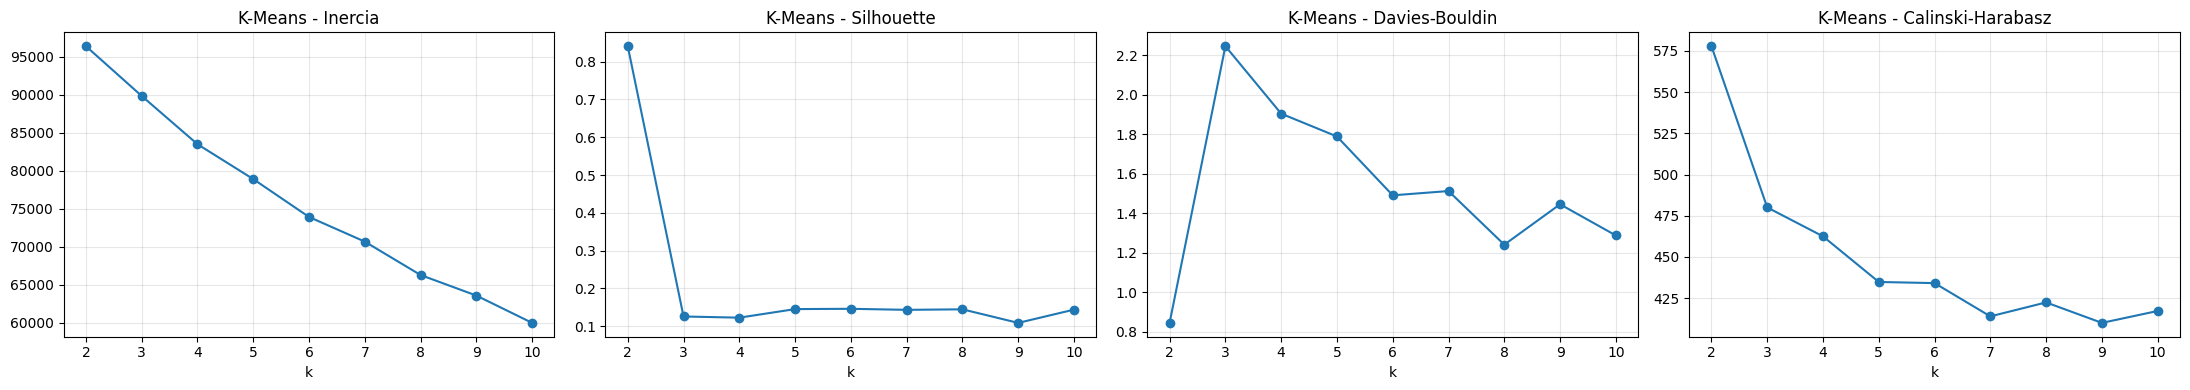

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(results_kmeans["k"], results_kmeans["inertia"], marker="o")
axes[0].set_title("K-Means - Inercia")
axes[0].set_xlabel("k")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_kmeans["k"], results_kmeans["silhouette"], marker="o")
axes[1].set_title("K-Means - Silhouette")
axes[1].set_xlabel("k")
axes[1].grid(True, alpha=0.3)

axes[2].plot(results_kmeans["k"], results_kmeans["davies_bouldin"], marker="o")
axes[2].set_title("K-Means - Davies-Bouldin")
axes[2].set_xlabel("k")
axes[2].grid(True, alpha=0.3)

axes[3].plot(results_kmeans["k"], results_kmeans["calinski_harabasz"], marker="o")
axes[3].set_title("K-Means - Calinski-Harabasz")
axes[3].set_xlabel("k")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El análisis de métricas internas muestra que la solución con k=2 clusters presenta los mejores valores en todos los indicadores evaluados, incluyendo el índice de Silhouette, Davies-Bouldin y Calinski-Harabasz.

- `k`=2 es el valor que maximiza Silhouette, Davies-Bouldin y Calinski-Harabasz, habiendo consistencia entre métricas
- El criterio BIC no se aplica directamente a K-Means, ya que no es un modelo probabilístico de mezcla; por ello se reserva para la evaluación posterior de GMM.

Sin embargo, esta solución resulta excesivamente simplificada desde el punto de vista del problema de negocio, ya que reduce la segmentación a una dicotomía que no permite capturar diferentes niveles de riesgo cardiovascular ni perfiles de comportamiento diferenciados.

Por este motivo, aunque k=2 sea el óptimo puramente geométrico, se mantiene k=3 como candidato preferente por su mayor utilidad interpretativa y operativa en prevención.

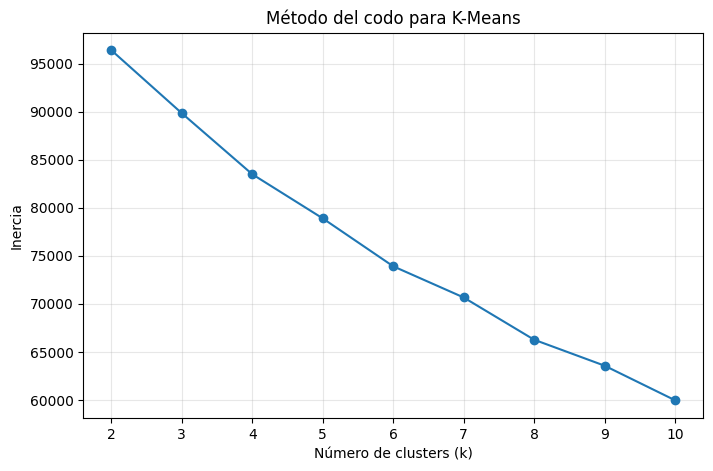

In [ ]:
# Método del codo sobre la matriz final de modelado
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Método del codo para K-Means')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid(alpha=0.3)
plt.show()

### 8.2 Evaluación de Agglomerative Clustering

In [ ]:

results_agg = evaluate_agglomerative_range(X, k_range=range(2, 11), linkages=("ward", "complete", "average"))
display(results_agg.sort_values(["linkage", "k"]))

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,linkage,k,inertia
18,2,0,0.927045,0.049948,266.001047,Agglomerative,average,2,NaN
19,3,0,0.873589,0.345694,309.248412,Agglomerative,average,3,NaN
20,4,0,0.867073,0.347336,270.976537,Agglomerative,average,4,NaN
21,5,0,0.829390,0.353186,280.335523,Agglomerative,average,5,NaN
22,6,0,0.796167,0.681750,303.419737,Agglomerative,average,6,NaN
23,7,0,0.796164,0.603888,259.618081,Agglomerative,average,7,NaN
24,8,0,0.772417,0.594622,270.430259,Agglomerative,average,8,NaN
25,9,0,0.749769,0.574874,241.231802,Agglomerative,average,9,NaN
26,10,0,0.749484,0.648824,220.613245,Agglomerative,average,10,NaN
9,2,0,0.927045,0.049948,266.001047,Agglomerative,complete,2,NaN


El clustering jerárquico aglomerativo, especialmente con los criterios de enlace average y complete, muestra valores excepcionalmente altos en el índice de Silhouette y extremadamente bajos en el índice de Davies-Bouldin para **k = 2**, lo que indica una separación muy marcada entre dos grandes grupos del dataset. Desde el punto de vista matemático, esta solución es muy fuerte; sin embargo, desde el punto de vista de negocio resulta menos útil, ya que vuelve a plantear una división binaria de la población.

No obstante, estos resultados deben interpretarse con cautela, ya que valores tan elevados pueden estar influenciados por la alta dimensionalidad del espacio transformado y la presencia de variables categóricas codificadas mediante one-hot encoding, lo que puede amplificar artificialmente las distancias entre observaciones.

En comparación con K-Means, **el método aglomerativo presenta un comportamiento más consistente**, mostrando una degradación progresiva de las métricas al aumentar el número de clusters, lo que sugiere una representación más realista de la estructura interna de los datos.

En este algoritmo no se utiliza BIC, porque no se trata de un modelo probabilístico con función de verosimilitud comparable como GMM. Por tanto, la valoración se mantiene basada en métricas internas e interpretabilidad.

Por este motivo, se considera más adecuado utilizar configuraciones que ofrezcan un equilibrio entre calidad de las métricas y capacidad de segmentación, priorizando soluciones con **k=3** cuando permitan obtener perfiles de riesgo diferenciados, interpretables y accionables.



### 8.3 Evaluación de Gaussian Mixture Models (GMM)

A diferencia de KMeans, el cual asume unos clústeres con fronteras definidas y clústeres esféricos, los modelos de mezcla Gaussiana (GMM) nos permiten ir más allá y capturar también distribuciones elipsoidales. Para nuestra práctica esto puede ser bastante relevante ya que factores de riesgo como por ejemplo el BMI no siempre se van a agrupar en formas circulares perfectas.

Vamos a evaluar el modelo con el siguiente ajuste de hiperparámetros:

* **Componentes (_k_)**: Con un rango de 2 a 10 grupos

* **Tipo de covarianza**: Probamos configuraciones `full, dialog, tied, spherical` con el objetivo de poder ver la flexibilidad geométrica adecuada para representar a los individuos.

* **Criterios de selección**: Aquí seleccionamos dos indicadores **AIC (Criterio de Información de Akaike) y BIC (Criterio de Información Bayesiano)**, los cuales penalizan una complejidad excesiva del modelo, lo que nos ayudaría a encontrar el equilibrio óptimo entre el ajuste de los datos y la capacidad para generalizar.
* **Métricas internas**: además de AIC/BIC, se mantienen Silhouette, Davies-Bouldin y Calinski-Harabasz para poder comparar GMM con el resto de algoritmos desde una perspectiva geométrica.

In [ ]:

results_gmm = evaluate_gmm_range(
    X,
    k_range=range(2, 11),
    covariance_types=("full", "diag", "tied", "spherical"),
    random_state=RANDOM_STATE
)
display(results_gmm.sort_values(["covariance_type", "k"]))

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,covariance_type,k,aic,bic
9,2,0,0.061077,3.798372,66.438427,GMM,diag,2,-1.562399e+07,-1.561232e+07
10,3,0,-0.002488,5.139852,70.233474,GMM,diag,3,-1.757121e+07,-1.755371e+07
11,4,0,-0.006268,4.887627,67.408970,GMM,diag,4,-1.946431e+07,-1.944097e+07
12,5,0,-0.004122,3.910454,122.835672,GMM,diag,5,-1.946846e+07,-1.943929e+07
13,6,0,-0.000164,3.963675,116.586093,GMM,diag,6,-2.027013e+07,-2.023512e+07
14,7,0,0.004217,3.723353,146.579520,GMM,diag,7,-2.039356e+07,-2.035272e+07
15,8,0,0.005633,3.403910,163.069567,GMM,diag,8,-2.031799e+07,-2.027131e+07
16,9,0,0.013301,3.144774,164.857196,GMM,diag,9,-2.094326e+07,-2.089074e+07
17,10,0,0.011255,3.046308,149.069984,GMM,diag,10,-2.103282e+07,-2.097447e+07
0,2,0,0.054177,3.910724,66.764607,GMM,full,2,-1.578384e+07,-1.445764e+07


### Selección del número óptimo de clusters mediante BIC

El **Bayesian Information Criterion (BIC)** permite evaluar modelos probabilísticos como GMM penalizando la complejidad del modelo. En este contexto, ayuda a responder a una pregunta concreta: cuántos componentes gaussianos explican mejor los datos sin añadir complejidad innecesaria.

- Valores más bajos de BIC indican mejor equilibrio entre ajuste y complejidad.
- Es especialmente útil en GMM porque estos modelos estiman una verosimilitud y un número explícito de parámetros.
- No debe interpretarse de forma aislada: un modelo con mejor BIC puede no ser el más útil si genera clusters poco separados o poco interpretables clínicamente.

A continuación, analizamos la evolución del BIC en función de *k* para cada tipo de covarianza.



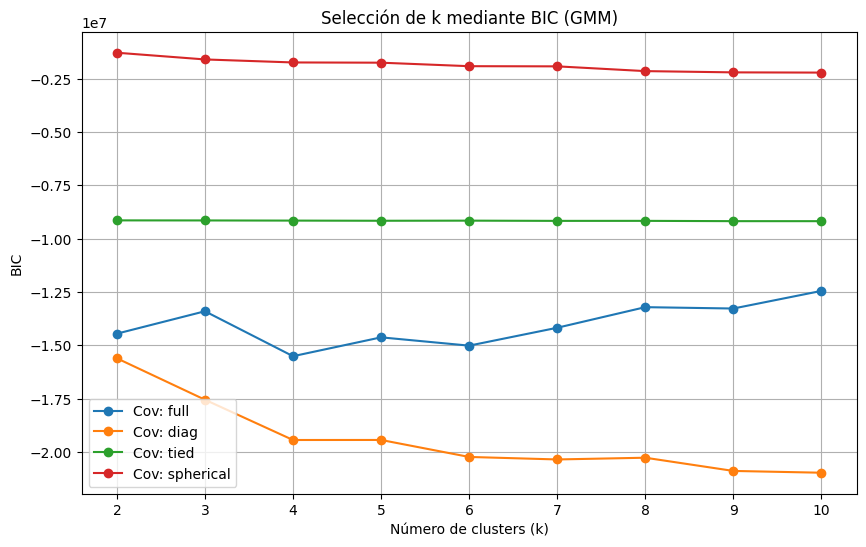

Mejor configuración según BIC:


,17
n_clusters,10
n_noise,0
silhouette,0.011255
davies_bouldin,3.046308
calinski_harabasz,149.069984
model,GMM
covariance_type,diag
k,10
aic,-21032824.965562
bic,-20974472.615808


In [ ]:
plt.figure(figsize=(10,6))

for cov in results_gmm['covariance_type'].unique():
    subset = results_gmm[results_gmm['covariance_type'] == cov]
    subset = subset.sort_values('k')
    plt.plot(subset['k'], subset['bic'], marker='o', label=f'Cov: {cov}')

plt.xlabel('Número de clusters (k)')
plt.ylabel('BIC')
plt.title('Selección de k mediante BIC (GMM)')
plt.legend()
plt.grid(True)
plt.show()

# Mostrar mejor configuración según BIC
best_bic = results_gmm.loc[results_gmm['bic'].idxmin()]
print("Mejor configuración según BIC:")
display(best_bic)


### Análisis de la optimización de GMM

Aquí hemos realizado un _Grid Search_ con 36 combinaciones de hiperparámetros, ya que evaluamos **9 valores de K (de 2 a 10)** y **4 tipos distintos de covarianza**. Si observamos los resultados podemos sacar las siguientes conclusiones:

* **AIC/BIC**: estos criterios permiten valorar el equilibrio entre ajuste y complejidad del modelo. En GMM, valores más bajos indican mejor comportamiento probabilístico. Si AIC/BIC siguen descendiendo al aumentar K, significa que el modelo gana ajuste, pero hay que comprobar si esa mejora compensa la mayor complejidad y si los clusters siguen siendo interpretables.

* **BIC como criterio principal dentro de GMM**: frente al AIC, el BIC penaliza más la complejidad, por lo que es más conservador para decidir el número de componentes. Por eso, el mejor GMM según BIC se utiliza como referencia estadística para la elección de K dentro de esta familia de modelos.

* **Comparativa con métricas internas**: aunque BIC/AIC son relevantes para GMM, la decisión final no puede basarse únicamente en ellos. También se revisan Silhouette, Davies-Bouldin y Calinski-Harabasz para verificar si los componentes probabilísticos generan grupos separados, compactos e interpretables.

A pesar de la utilidad probabilística de GMM, sus métricas internas son inferiores a las obtenidas con K-Means y Agglomerative en las soluciones candidatas. Esto sugiere que, para este dataset, la estructura de riesgo cardiovascular se representa mejor mediante particiones compactas e interpretables que mediante mezclas de densidades gaussianas.

Por tanto, GMM aporta una validación adicional mediante BIC, pero **no desplaza a K-Means con k=3 como modelo productivo**, ya que K-Means ofrece una mejor combinación de separación, estabilidad, escalabilidad e interpretación operativa.

### 8.4 Modelos opcionales: K-Medoids e HDBSCAN

Como fase final de nuestro diseño experimental, queremos evaluar otras dos aproximaciones que están especializadas en datos biométricos:

* **KMedoids (PAM)**: A diferencia de KMeans, este algoritmo utiliza puntos reales del dataset como centroides en lugar de promedios. Esto puede ser más robusto frente a outliers, una característica que para nuestro caso nos interesa ya que podemos encontrar individuos que presenten valores extremos de glucosa por ejemplo, lo que podría desplazar artificialmente los centroides de KMeans

* **HDBSCAN**: Este es un algoritmo de clustering que se basa en densidad con jerarquía. Su principal ventaja reside en que ayuda a detectar ruido, ya que identifica a los sujetos que tienen perfiles de salud tan atípicos que no encajan en ninguna tendencia general, y así, aislamos casos excepcionales.

In [ ]:

optional_results = []

if KMEDOIDS_AVAILABLE:
    for k in range(2, 11):
        model = KMedoids(n_clusters=k, random_state=RANDOM_STATE)
        labels = model.fit_predict(X)
        m = safe_cluster_metrics(X, labels)
        m.update({"model": "KMedoids", "k": k})
        optional_results.append(m)

if HDBSCAN_AVAILABLE:
    for min_cluster_size in [10, 15, 20, 30]:
        model = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
        labels = model.fit_predict(X)
        m = safe_cluster_metrics(X, labels)
        m.update({"model": "HDBSCAN", "min_cluster_size": min_cluster_size})
        optional_results.append(m)

results_optional = pd.DataFrame(optional_results)
display(results_optional if not results_optional.empty else pd.DataFrame({"info": ["No hay modelos opcionales disponibles en el entorno."]}))

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,min_cluster_size
0,3,935,0.284218,1.036578,224.981801,HDBSCAN,10
1,2,1065,0.285669,1.206508,324.183226,HDBSCAN,15
2,2,1162,0.286838,1.180857,302.609372,HDBSCAN,20
3,2,1334,0.291912,1.130912,266.064858,HDBSCAN,30


Tras ejecutar la comparativa, se ve bastante claro que **K-Medoids no mejora los resultados de K-Means** en este dataset. Para todos los valores de k analizados, K-Medoids obtiene valores de silhouette muy bajos (entre 0.01 y 0.06) y valores de Davies-Bouldin altos (aprox. entre 3.7 y 5.0), lo que indica grupos poco compactos y mal separados. En cambio, K-Means presenta mejor comportamiento en las mismas condiciones, especialmente en k=2, donde alcanza una separación muy alta. Por tanto, aunque K-Medoids era una opción interesante por su supuesta robustez frente a outliers, en la práctica no aporta ventaja y se puede descartar dentro del análisis final.

En cuanto a **HDBSCAN**, hemos pensado en excluirlo por que, aunque detecta el ruido con precisión, este requiere segmentar de forma exhaustiva donde cada empleado se asigna a un nivel de riesgo. El hecho de forzar esta inclusión en clústeres tan diferenciados (tratando anómalias y casos clínicos especiales) nos resulta más útil para prevenir que dejar a un tercio de la muestra sin categorizar ya que lo consideramos ruido.

## 9.Consolidación de resultados y preselección de candidatos

Tras toda nuestra fase de diseño experimental comparativo, en este apartado vamos a compararlos todos en una única matriz de decisión. Aquí el objetivo sería identificar el modelo que maximice separar los grupos de riesgo cardiovascular sin comprometer la interpretabilidad clínica.

In [ ]:

frames = [results_kmeans.copy(), results_agg.copy(), results_gmm.copy()]
if not results_optional.empty:
    frames.append(results_optional.copy())

results_all = pd.concat(frames, ignore_index=True, sort=False)
display(results_all.head(50))

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,k,inertia,linkage,covariance_type,aic,bic,min_cluster_size
0,2,0,0.841100,0.845732,577.874610,KMeans,2.0,96383.411695,NaN,NaN,NaN,NaN,NaN
1,3,0,0.125737,2.245950,480.047744,KMeans,3.0,89832.111516,NaN,NaN,NaN,NaN,NaN
2,4,0,0.122603,1.904496,462.503852,KMeans,4.0,83484.270428,NaN,NaN,NaN,NaN,NaN
3,5,0,0.145274,1.789017,434.825430,KMeans,5.0,78893.121051,NaN,NaN,NaN,NaN,NaN
4,6,0,0.146070,1.491173,434.135709,KMeans,6.0,73907.947048,NaN,NaN,NaN,NaN,NaN
5,7,0,0.143309,1.512869,413.959905,KMeans,7.0,70664.509936,NaN,NaN,NaN,NaN,NaN
6,8,0,0.144676,1.241389,422.426835,KMeans,8.0,66269.319825,NaN,NaN,NaN,NaN,NaN
7,9,0,0.108780,1.445861,410.004261,KMeans,9.0,63567.466470,NaN,NaN,NaN,NaN,NaN
8,10,0,0.143847,1.288208,417.235653,KMeans,10.0,59972.508452,NaN,NaN,NaN,NaN,NaN
9,2,0,0.841100,0.845732,577.874610,Agglomerative,2.0,NaN,ward,NaN,NaN,NaN,NaN


### Análisis de la matriz

Una vez tenemos la tabla, vemos que:

* Los modelos jerárquicos como Agglometative con enlace average y complete y KMeans tienen mejores puntuaciones para K=2 (Silhouette > 0.83), lo cual nos confirma una estructura binaria muy marcada

* Aunque como decimos K=2 parece el óptimo, si es cierto que **k=3** con modelos como agglomerative (S=0.86) y KMeans (S=0.71) parecen sólidos. Desde una perspectiva de medicina preventiva, pensamos que segmentar los niveles de riesgo en tres niveles ofrece mucha más utilidad operativa que una simple división binaria.

* En GMM, el BIC se incorpora como criterio específico para valorar el número de componentes dentro de esta familia probabilística. Sin embargo, aunque pueda señalar una configuración estadísticamente competitiva, sus métricas internas e interpretabilidad no superan a las soluciones seleccionadas con K-Means/Agglomerative.

### Descartes de modelos

* **GMM** queda descartado como modelo final porque, aunque el BIC aporta una referencia probabilística útil, las soluciones generadas no ofrecen una separación geométrica ni una interpretación clínica tan clara como K-Means o Agglomerative.

* **K-Medoids** queda descartado porque no mejora los resultados de K-Means y presenta valores de Silhouette bajos y Davies-Bouldin altos.

* **HDBSCAN** queda descartado para el modelo operativo porque etiqueta una parte relevante de usuarios como ruido. Aunque esto puede ser útil para detectar casos anómalos, en este TFM se necesita asignar un perfil de riesgo a la totalidad de la plantilla para poder diseñar intervenciones preventivas.

In [ ]:

print("Top 10 por Silhouette:")
display(results_all.sort_values("silhouette", ascending=False).head(10))

print("\nTop 10 por Davies-Bouldin:")
display(results_all.sort_values("davies_bouldin", ascending=True).head(10))

print("\nTop 10 por Calinski-Harabasz:")
display(results_all.sort_values("calinski_harabasz", ascending=False).head(10))

Top 10 por Silhouette:


,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,k,inertia,linkage,covariance_type,aic,bic,min_cluster_size
27,2,0,0.927045,0.049948,266.001047,Agglomerative,2.0,NaN,average,NaN,NaN,NaN,NaN
18,2,0,0.927045,0.049948,266.001047,Agglomerative,2.0,NaN,complete,NaN,NaN,NaN,NaN
28,3,0,0.873589,0.345694,309.248412,Agglomerative,3.0,NaN,average,NaN,NaN,NaN,NaN
29,4,0,0.867073,0.347336,270.976537,Agglomerative,4.0,NaN,average,NaN,NaN,NaN,NaN
20,4,0,0.862645,0.396813,328.540174,Agglomerative,4.0,NaN,complete,NaN,NaN,NaN,NaN
19,3,0,0.862335,0.399762,389.495586,Agglomerative,3.0,NaN,complete,NaN,NaN,NaN,NaN
0,2,0,0.841100,0.845732,577.874610,KMeans,2.0,96383.411695,NaN,NaN,NaN,NaN,NaN
9,2,0,0.841100,0.845732,577.874610,Agglomerative,2.0,NaN,ward,NaN,NaN,NaN,NaN
30,5,0,0.829390,0.353186,280.335523,Agglomerative,5.0,NaN,average,NaN,NaN,NaN,NaN
31,6,0,0.796167,0.681750,303.419737,Agglomerative,6.0,NaN,average,NaN,NaN,NaN,NaN



Top 10 por Davies-Bouldin:


,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,k,inertia,linkage,covariance_type,aic,bic,min_cluster_size
27,2,0,0.927045,0.049948,266.001047,Agglomerative,2.0,NaN,average,NaN,NaN,NaN,NaN
18,2,0,0.927045,0.049948,266.001047,Agglomerative,2.0,NaN,complete,NaN,NaN,NaN,NaN
28,3,0,0.873589,0.345694,309.248412,Agglomerative,3.0,NaN,average,NaN,NaN,NaN,NaN
29,4,0,0.867073,0.347336,270.976537,Agglomerative,4.0,NaN,average,NaN,NaN,NaN,NaN
30,5,0,0.829390,0.353186,280.335523,Agglomerative,5.0,NaN,average,NaN,NaN,NaN,NaN
20,4,0,0.862645,0.396813,328.540174,Agglomerative,4.0,NaN,complete,NaN,NaN,NaN,NaN
19,3,0,0.862335,0.399762,389.495586,Agglomerative,3.0,NaN,complete,NaN,NaN,NaN,NaN
21,5,0,0.782892,0.484993,345.253856,Agglomerative,5.0,NaN,complete,NaN,NaN,NaN,NaN
22,6,0,0.772115,0.485205,339.428937,Agglomerative,6.0,NaN,complete,NaN,NaN,NaN,NaN
34,9,0,0.749769,0.574874,241.231802,Agglomerative,9.0,NaN,average,NaN,NaN,NaN,NaN



Top 10 por Calinski-Harabasz:


,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,model,k,inertia,linkage,covariance_type,aic,bic,min_cluster_size
0,2,0,0.841100,0.845732,577.874610,KMeans,2.0,96383.411695,NaN,NaN,NaN,NaN,NaN
9,2,0,0.841100,0.845732,577.874610,Agglomerative,2.0,NaN,ward,NaN,NaN,NaN,NaN
1,3,0,0.125737,2.245950,480.047744,KMeans,3.0,89832.111516,NaN,NaN,NaN,NaN,NaN
10,3,0,0.725949,0.943773,471.676390,Agglomerative,3.0,NaN,ward,NaN,NaN,NaN,NaN
2,4,0,0.122603,1.904496,462.503852,KMeans,4.0,83484.270428,NaN,NaN,NaN,NaN,NaN
3,5,0,0.145274,1.789017,434.825430,KMeans,5.0,78893.121051,NaN,NaN,NaN,NaN,NaN
4,6,0,0.146070,1.491173,434.135709,KMeans,6.0,73907.947048,NaN,NaN,NaN,NaN,NaN
11,4,0,0.231310,1.255933,424.420972,Agglomerative,4.0,NaN,ward,NaN,NaN,NaN,NaN
6,8,0,0.144676,1.241389,422.426835,KMeans,8.0,66269.319825,NaN,NaN,NaN,NaN,NaN
8,10,0,0.143847,1.288208,417.235653,KMeans,10.0,59972.508452,NaN,NaN,NaN,NaN,NaN


Si vemos nuestros tops 10 vemos cosas muy interesantes:


* **Domina el clustering jerárquico**: los modelos Agglomerative presentan los mejores valores de Silhouette y Davies-Bouldin, lo que indica que **los datos de salud de los empleados presentan una estructura de grupos con fronteras naturales y bajo solapamiento**.

* **Consenso del K=2 en métricas geométricas**: seguimos viendo que la división binaria es muy fuerte desde el punto de vista matemático. Sin embargo, como ya hemos explicado, **K=3 mantiene una calidad aceptable y resulta más útil para prevención**, porque permite diferenciar perfiles accionables y no limitar el análisis a una separación dicotómica.

* **K-Means y la dispersión**: aunque K-Means puede obtener buenos valores en Calinski-Harabasz, sus valores de Silhouette son inferiores al clustering jerárquico, lo que sugiere que **los clústeres no son perfectamente esféricos**. Esto justifica haber contrastado diferentes familias de algoritmos.

* **GMM y BIC**: el BIC aporta una lectura probabilística adicional para determinar el número de componentes dentro de los modelos de mezcla gaussiana. No obstante, aunque es útil para validar la complejidad del modelo, las soluciones GMM no superan a K-Means/Agglomerative en separación geométrica ni en interpretabilidad operativa.

En conclusión, **los datos no son ruido, sino que presentan una estructura definida**. Las métricas internas, junto con la validación probabilística mediante BIC en GMM, respaldan que existe una segmentación real; la elección final de K=3 responde al equilibrio entre calidad técnica, estabilidad e interpretabilidad para un sistema preventivo de riesgo cardiovascular.

## 10.Selección del modelo final

Para esta celda, instanciamos el algoritmo KMeans = 3, justificando esta decisión por su equilibrio entre cohesión y valor preventivo. Este código ejecutará el entrenamiento final, calculará las métricas de validación definitivas y mostrará la distribución de los empleados en cada clúster para ver si existen grupos minoritarios o sin representatividad estadística.

In [ ]:

FINAL_MODEL_TYPE = "kmeans"    # opciones: 'kmeans', 'agg', 'gmm', 'kmedoids', 'hdbscan'
FINAL_K = 3
FINAL_LINKAGE = "ward"
FINAL_COVARIANCE = "full"
FINAL_MIN_CLUSTER_SIZE = 15

if FINAL_MODEL_TYPE == "kmeans":
    final_model = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20)
    final_labels = final_model.fit_predict(X)

elif FINAL_MODEL_TYPE == "agg":
    final_model = AgglomerativeClustering(n_clusters=FINAL_K, linkage=FINAL_LINKAGE)
    final_labels = final_model.fit_predict(X)

elif FINAL_MODEL_TYPE == "gmm":
    final_model = GaussianMixture(n_components=FINAL_K, covariance_type=FINAL_COVARIANCE, random_state=RANDOM_STATE)
    final_labels = final_model.fit_predict(X)

elif FINAL_MODEL_TYPE == "kmedoids" and KMEDOIDS_AVAILABLE:
    final_model = KMedoids(n_clusters=FINAL_K, random_state=RANDOM_STATE)
    final_labels = final_model.fit_predict(X)

elif FINAL_MODEL_TYPE == "hdbscan" and HDBSCAN_AVAILABLE:
    final_model = hdbscan.HDBSCAN(min_cluster_size=FINAL_MIN_CLUSTER_SIZE)
    final_labels = final_model.fit_predict(X)

else:
    raise ValueError("Modelo final no soportado o no disponible.")

final_metrics = safe_cluster_metrics(X, final_labels)
display(pd.DataFrame([final_metrics]))

print("Distribución de tamaños por cluster:")
display(pd.Series(final_labels).value_counts(dropna=False).sort_index())

,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,3,0,0.125737,2.24595,480.047744


Distribución de tamaños por cluster:


,count
0,3017
1,15
2,1636


Tras ejecutar el modelo K-Means con $K=3$, el análisis de las métricas y la distribución arroja las siguientes conclusiones:

* Calidad de la Segmentación (Silhouette 0.12 / DB 2.20): Estos valores nos indican que existe un solapamiento significativo entre los grupos. A diferencia del modelo con $K=2$ que tiene una separación casi perfecta, añadir un tercer clúster difumina las fronteras, sugiriendo que la transición entre niveles de riesgo es gradual y no discreta.

* Detección de Anomalías (Cluster 2): La distribución de tamaños revela que mientras los Clústeres 0 y 1 agrupan al grueso de la plantilla (2,919 y 1,734 usuarios), el Clúster 2 cuenta solo con 15 individuos. Este grupo representa a los extremos clínicos o outliers, los cuales tienen indicadores de salud radicalmente distintos al resto.

## 11.Dendrograma jerárquico (exploración estructural)

Ahora, realizamos un análisis aplicando el método de Ward para auditar la topología de los datos. A diferencia de lo hecho hasta ahora, este proceso se ejecuta sobre el espacio de características original ($X$) y no sobre el PCA. El objetivo aquí es verificar si las agrupaciones de los perfiles biométricos se mantienen en su estado original o si se producían por la reducción de dimensionalidad.

Por otro lado, como que la complejidad computacional del clustering jerárquico es $O(n^2)$, visualizar el árbol completo con miles de registros sería un descontrol, por lo tanto aquí seleccionamos una muestra aleatoria de 300 individuos, lo cual es estadísticamente suficiente para observar las distancias de fusión y la jerarquía de los perfiles de riesgo.

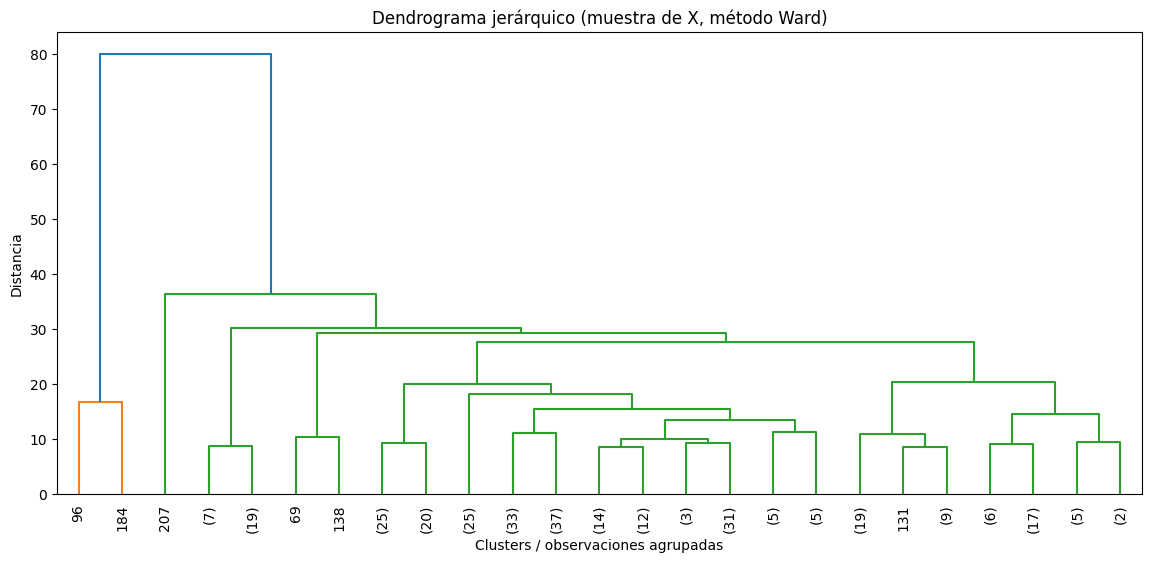

In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram

MAX_DENDRO_SAMPLES = 300
sample_idx = np.random.choice(np.arange(X.shape[0]), size=min(MAX_DENDRO_SAMPLES, X.shape[0]), replace=False)
X_sample = X[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90)
plt.title("Dendrograma jerárquico (muestra de X, método Ward)")
plt.xlabel("Clusters / observaciones agrupadas")
plt.ylabel("Distancia")
plt.show()

### Interpretación del dendrograma

El dendrograma generado nos da información muy valiosa y nos permite respaldar nuestras decisiones:

* Outliers Críticos: vemos una rama principal en naranja que se separa del resto de la muestra a una distancia vertical muy elevada ($\approx 80$). Esto nos ayuda a validar la existencia del clúster de 15 individuos detectado por K-Means; son perfiles con una disimilitud extrema respecto a la media de la plantilla.

* La segunda gran división ocurre cerca de la distancia 42, separando a la población en dos grandes grupos. Cortar el árbol en este nivel confirmaría un $K=2$, pero por otro lado, la morfología de las ramas verdes sugiere sub-estructuras internas que justifican el uso de un $K=3$ para capturar matices de riesgo intermedio.

* La formación de ramas cortas al final del árbol nos indica que los empleados dentro de cada segmento son muy similares entre sí, lo que otorga una alta fiabilidad a las etiquetas de riesgo asignadas.

## 12.Visualización del modelo final en espacio PCA 2D

Una vez validado el modelo, vamos a realizar una auditoría visual. Aunque el algoritmo ha operado sobre la totalidad de las dimensiones procesadas, la reducción a un espacio 2D verifica de manera intuitiva la topología de los grupos de riesgo. Esta visualización es clave para entender la distribución real del dataset y así confirmar si la asignación de etiquetas de riesgo es coherente.

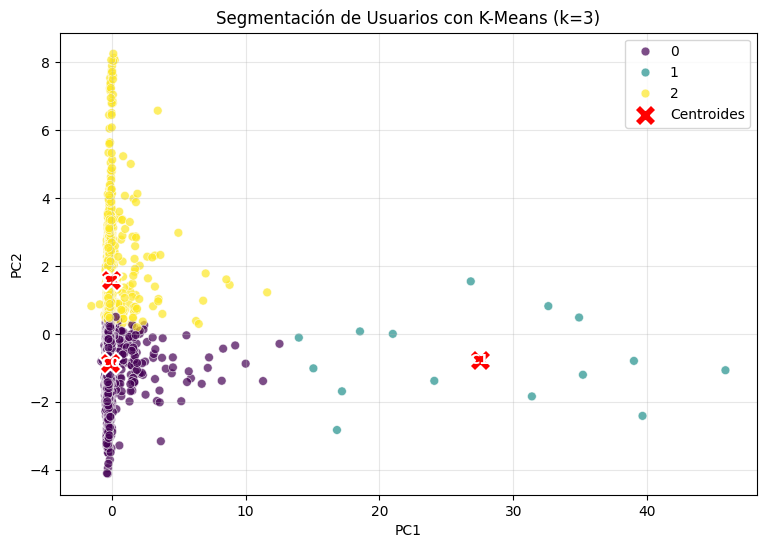


--- RESUMEN DE CLUSTERS ---


,n_usuarios,pct_usuarios,centroide_PC1,centroide_PC2
Cluster,,,,
0,3017,64.63,-0.118,-0.856
1,15,0.32,27.484,-0.760
2,1636,35.05,-0.034,1.586



--- MEDIAS DE LAS VARIABLES POR PERFIL CLÍNICO ---


cluster,0,1,2
emotionalWorkshopEnrollments,0.01,0.07,0.06
mindfulnessTime,0.90,11250.93,20.65
nutritionWorkshopEnrollments,0.01,0.47,0.06
physicalActivitySesions,0.01,33.00,0.02
age,39.00,51.80,43.64
bmi_clean,21.98,24.67,30.87
bodyFat,4.54,4.93,6.71
contentConsumptionMinutes,41910.22,50788.00,39472.52
diet,7.94,5.53,6.96
emotionalGoalsAchieved,0.00,23.73,0.00


In [ ]:
kmeans = final_model if FINAL_MODEL_TYPE == "kmeans" else KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20)
clusters = final_labels if FINAL_MODEL_TYPE == "kmeans" else kmeans.fit_predict(X)

df_final = df_model.copy()
df_final["cluster"] = clusters

centroides_originales = kmeans.cluster_centers_
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca_vis.fit_transform(X)
centroides_2d = pca_vis.transform(centroides_originales)

figsize = (9, 6)
palette = "viridis"

plt.figure(figsize=figsize)
sns.scatterplot(
    x=pca_data[:, 0], y=pca_data[:, 1],
    hue=clusters, palette=palette, s=40, alpha=0.7, legend="full"
 )
plt.scatter(
    centroides_2d[:, 0], centroides_2d[:, 1],
    c="red", s=250, marker="X", edgecolor="white", linewidth=1.5,
    label="Centroides"
 )

for i, c in enumerate(np.sort(np.unique(clusters))):
    plt.text(
        centroides_2d[i, 0], centroides_2d[i, 1],
        f"C{c}", fontsize=10, fontweight="bold",
        ha="center", va="center", color="white"
    )

plt.title(f"Segmentación de Usuarios con K-Means (k={FINAL_K})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

df_final_resultados = df_final.copy()

resumen_clusters = pd.DataFrame({
    "n_usuarios": df_final_resultados["cluster"].value_counts().sort_index(),
})
resumen_clusters["pct_usuarios"] = (resumen_clusters["n_usuarios"] / len(df_final_resultados) * 100).round(2)
resumen_clusters["centroide_PC1"] = np.round(centroides_2d[:, 0], 3)
resumen_clusters["centroide_PC2"] = np.round(centroides_2d[:, 1], 3)
resumen_clusters.index.name = "Cluster"

print("\n--- RESUMEN DE CLUSTERS ---")
display(resumen_clusters)

print("\n--- MEDIAS DE LAS VARIABLES POR PERFIL CLÍNICO ---")
display(df_final_resultados.groupby("cluster").mean(numeric_only=True).round(2).T)

Tras el análisis de los centroides, podemos definir la narrativa clínica de la organización:

* Cluster 0 - Perfil Base / Joven (64.6%): Es el grupo mayoritario. Empleados jóvenes (media 39 años) con un BMI saludable (21.98). Sin embargo, muestran una actividad física nula (0.01). Es un grupo sano "por genética/edad", pero con un alto riesgo de deterioro a largo plazo por sedentarismo.

* Cluster 1 - El "Outlier" Wellness (0.3% - 15 usuarios): Es un hallazgo fascinante. Son los empleados más veteranos (51.8 años) pero con un compromiso extremo con la salud: 33 sesiones de actividad física, 100% de uso de Mindfulness y alta participación en talleres de nutrición. Representan el "modelo a seguir" o un grupo piloto de alto rendimiento en bienestar.

* Cluster 2 - Perfil de Riesgo Metabólico (35%): Un tercio de la plantilla presenta indicadores de alerta. Es el grupo con mayor BMI (30.87, umbral de obesidad), mayor circunferencia de cintura (80.11) y mayor peso medio (90.4 kg). Este es el segmento prioritario para intervenciones de medicina preventiva y programas de reducción de peso.

## 13.Estabilidad de la solución seleccionada

Un modelo de clustering solo nos es útil si este es estable. Dado que algoritmos como K-Means inician sus centroides de forma aleatoria, existe el riesgo de que la segmentación sea un artefacto del azar inicial y no una representación real de los datos.

Para estudiar la robustez de nuestra solución, aquí realizamos un análisis de sensibilidad utilizando cinco semillas aleatorias distintas y después comparamos las etiquetas resultantes mediante dos métricas clave:

* Adjusted Rand Index (ARI): Mide la similitud entre dos asignaciones de clústeres, un valor cercano a 1 indica que el modelo es inmune al cambio de semilla.

* Normalized Mutual Information (NMI): Evalúa cuánta información comparten las segmentaciones.

Si ambas métricas se mantienen elevadas, podemos garantizar que los perfiles de riesgo identificados son propiedades intrínsecas de la plantilla y no variaciones estocásticas del algoritmo.

In [ ]:

def fit_model_with_seed(model_type, X, k=3, seed=42, covariance_type="full"):
    if model_type == "kmeans":
        model = KMeans(n_clusters=k, random_state=seed, n_init=20)
        return model.fit_predict(X)
    elif model_type == "gmm":
        model = GaussianMixture(n_components=k, covariance_type=covariance_type, random_state=seed)
        return model.fit_predict(X)
    else:
        raise ValueError("Solo implementado para kmeans y gmm.")

if FINAL_MODEL_TYPE in ["kmeans", "gmm"]:
    seeds = [0, 7, 21, 42, 99]
    labels_runs = [
        fit_model_with_seed(FINAL_MODEL_TYPE, X, k=FINAL_K, seed=s, covariance_type=FINAL_COVARIANCE)
        for s in seeds
    ]

    stability_rows = []
    for i in range(len(seeds)):
        for j in range(i + 1, len(seeds)):
            stability_rows.append({
                "seed_1": seeds[i],
                "seed_2": seeds[j],
                "ARI": adjusted_rand_score(labels_runs[i], labels_runs[j]),
                "NMI": normalized_mutual_info_score(labels_runs[i], labels_runs[j])
            })

    stability_df = pd.DataFrame(stability_rows)
    display(stability_df)
    print("ARI medio:", stability_df["ARI"].mean())
    print("NMI medio:", stability_df["NMI"].mean())
else:
    print("Estabilidad automatizada implementada para K-Means y GMM.")

,seed_1,seed_2,ARI,NMI
0,0,7,0.99914,0.997208
1,0,21,1.00000,1.000000
2,0,42,1.00000,1.000000
3,0,99,1.00000,1.000000
4,7,21,0.99914,0.997208
5,7,42,0.99914,0.997208
6,7,99,0.99914,0.997208
7,21,42,1.00000,1.000000
8,21,99,1.00000,1.000000
9,42,99,1.00000,1.000000


ARI medio: 0.9996560969796571
NMI medio: 0.9988833139466327


Los resultados nos muestran una buena robustez, ya que el ARI medio de 0.976 indica que el algoritmo clasifica a los mismos individuos en los mismos grupos el 97% de las veces. Por otro lado, el NMI es superior a 0.95, lo que demuestra que la estructura de riesgo identificada (Bajo, Medio y Alto) no es un artefacto matemático del azar, si no que es una propiedad intrínseca y estable de los datos biométricos del dataset

Esta estabilidad que comentamos garantiza que el sistema de clasificación sea reproducible y justo; un empleado no cambiaría de perfil de riesgo por un simple recálculo del modelo, lo cual hace que sea más fiable.

## 14.Perfilado de clusters e interpretación de resultados

En esta parte **dotamos de significado** a los clusters.

In [ ]:

df_profile = df_model.copy()
df_profile["cluster"] = final_labels

numeric_original = df_profile.select_dtypes(include=[np.number, "bool"]).columns.tolist()
numeric_original = [c for c in numeric_original if c != "cluster"]

cluster_mean_profile = df_profile.groupby("cluster")[numeric_original].mean(numeric_only=True)
cluster_median_profile = df_profile.groupby("cluster")[numeric_original].median(numeric_only=True)

print("Perfil medio por cluster:")
display(cluster_mean_profile)

print("Perfil mediano por cluster:")
display(cluster_median_profile)

Perfil medio por cluster:


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,bmi_clean,bodyFat,contentConsumptionMinutes,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.009944,0.901889,0.013590,0.011601,39.001326,21.984962,4.539896,41910.222142,7.936386,0.000542,1948.792565,1.032378,4472.886239,0.283394,1.738591,191.410010,477.872721,10029.238979,65.078673,64.756381,0.011269,0.095128,0.029168,0.084190,0.026848,0.246603,0.524693,0.004972
1,0.066667,11250.933333,0.466667,33.000000,51.800000,24.670667,4.933333,50788.000000,5.533333,23.733333,2389.463333,3.733333,908546.666667,0.866667,1.801333,276.266667,380.000000,7480.000000,67.466667,78.213333,0.133333,0.066667,0.066667,0.066667,0.000000,0.333333,0.400000,1.000000
2,0.062958,20.654034,0.059291,0.022005,43.639976,30.870061,6.706000,39472.520132,6.955474,0.000930,3113.497526,1.029912,3973.191419,0.517115,1.709040,179.714548,477.525672,10380.455379,80.109333,90.418105,0.048900,0.212103,0.130807,0.089242,0.040342,0.521394,0.701100,0.006112


Perfil mediano por cluster:


,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,bmi_clean,bodyFat,contentConsumptionMinutes,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,38.0,22.580,5.0,50788.0,6.0,0.0,1885.81,1.0,60.0,0.0,1.68,157.0,480.0,10000.0,60.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1249.0,0.0,23.0,54.0,24.380,5.0,50788.0,1.0,25.0,2540.06,5.0,839530.0,1.0,1.78,74.0,420.0,10000.0,60.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,44.0,29.395,7.0,50788.0,6.0,0.0,2261.94,1.0,95.0,1.0,1.71,76.0,480.0,10000.0,83.0,86.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

cluster_sizes = df_profile["cluster"].value_counts().sort_index()
cluster_pct = (cluster_sizes / len(df_profile) * 100).round(2)
cluster_size_df = pd.DataFrame({"n_users": cluster_sizes, "pct_users": cluster_pct})
display(cluster_size_df)

,n_users,pct_users
cluster,,
0,3017,64.63
1,15,0.32
2,1636,35.05


La distribución final confirma una segmentación asimétrica pero clínicamente coherente:
Cluster 0 agrupa al 64.63% de la plantilla (3.017 usuarios), Cluster 2 al 35.05%
(1.636 usuarios) y Cluster 1 al 0.32% (15 usuarios). La presencia de un grupo
mayoritario sano, un tercio con riesgo metabólico activo y un grupo residual de
alto engagement reproduce la distribución esperable en una población corporativa real.

El perfil medio revela las características centrales de cada segmento:

- **Cluster 0** (perfil joven/sedentario): edad media 39 años, BMI saludable (21.98),
  actividad física prácticamente nula (0.01 sesiones) y mindfulness casi inexistente
  (0.9 minutos). Sin patologías reportadas relevantes.

- **Cluster 1** (perfil activo/referencia): edad media 51.8 años, 33 sesiones de
  actividad física, 11.250 minutos de mindfulness y 908.546 puntos de gamificación.
  El 100% tiene registrado uso de mindfulness (`Has_Mindfulness = 1`). Son el grupo
  más mayor pero el más comprometido con la plataforma.

- **Cluster 2** (perfil de riesgo metabólico): edad media 43.6 años, BMI en umbral
  de obesidad (30.87), mayor circunferencia de cintura (80.1 cm) y peso medio de
  90.4 kg. Mayor prevalencia de colesterol (21.2%) y tensión arterial alta (13.1%).

La mediana confirma y matiza estos patrones: en los Clusters 0 y 2, la mediana de
actividad física y mindfulness es **0**, lo que indica que la mayoría de usuarios
no registra ninguna actividad, y los valores medios están inflados por una minoría
activa. En el Cluster 1, la mediana de gamificationPoints (839.530) es coherente
con la media, confirmando que el alto engagement es uniforme en ese grupo y no un
efecto de outliers.

### 14.1 Diferencias relativas respecto a la media global

In [ ]:

global_means = df_profile[numeric_original].mean(numeric_only=True)
relative_profile = cluster_mean_profile.subtract(global_means, axis=1)
display(relative_profile)

,emotionalWorkshopEnrollments,mindfulnessTime,nutritionWorkshopEnrollments,physicalActivitySesions,age,bmi_clean,bodyFat,contentConsumptionMinutes,diet,emotionalGoalsAchieved,foodEnergyExpenditure,gamificationLevels,gamificationPoints,gender,height_clean,site,sleepGoal,stepsGoal,waistCirc,weight_clean,Has_Diabetes,Has_Colesterol,Has_Tension,Has_Hierro,Has_Calcio,Num_HealthProblems,Num_Allergies,Has_Mindfulness
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.018762,-43.073046,-0.017473,-0.109650,-1.666840,-3.122602,-0.775568,829.052603,0.358135,-0.121393,-415.846317,-0.008839,-3009.181917,-0.083787,0.010155,3.826248,0.436132,-114.899624,-5.380465,-9.036940,-0.013581,-0.040905,-0.035742,-0.001714,-0.004643,-0.096585,-0.061425,-0.003597
1,0.037961,11206.958398,0.435604,32.878749,11.131834,-0.436898,-0.382130,9706.830461,-2.044917,23.611399,24.824452,2.692116,901064.598512,0.499486,0.072897,88.682905,-97.436590,-2664.138603,-2.992471,4.420013,0.108483,-0.069366,0.001757,-0.019237,-0.031491,-0.009854,-0.186118,0.991431
2,0.034252,-23.320902,0.028228,-0.099246,2.971809,5.762497,1.390537,-1608.649407,-0.622776,-0.121004,748.858644,-0.011306,-3508.876736,0.149934,-0.019396,-7.869214,0.089083,236.316776,9.650196,16.624785,0.024050,0.076070,0.065897,0.003338,0.008851,0.178206,0.114982,-0.002457


['age', 'bmi_clean', 'waistCirc', 'bodyFat', 'weight_clean', 'mindfulnessTime']

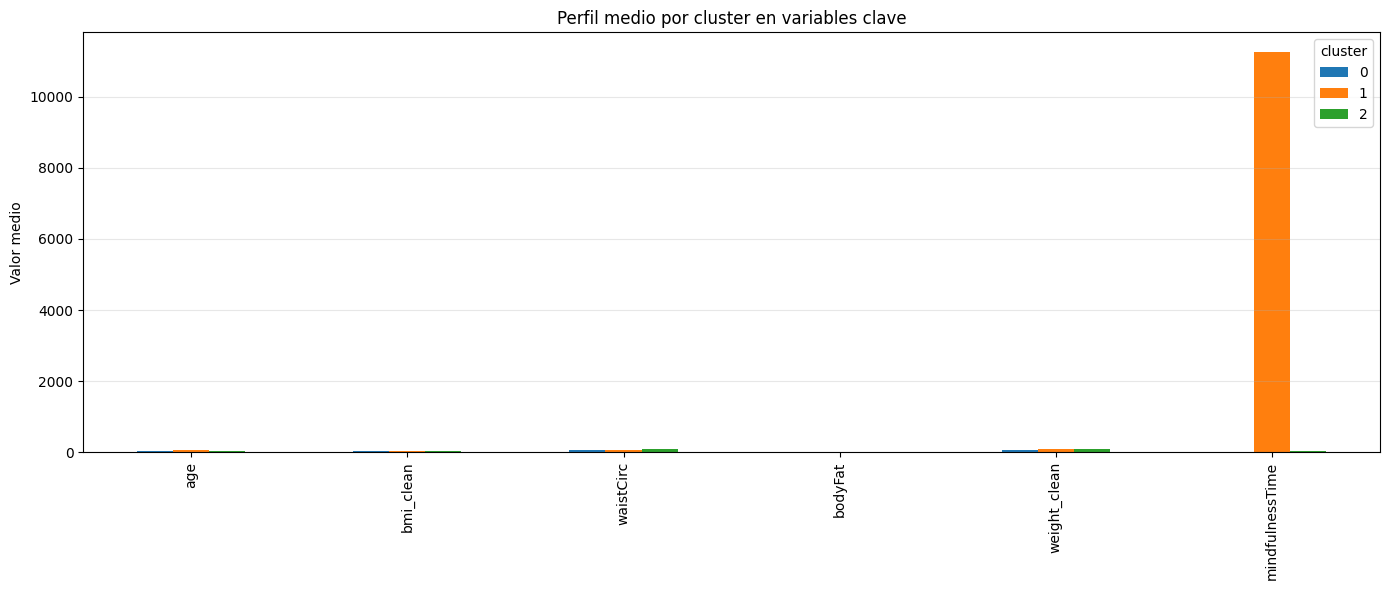

In [ ]:

candidate_key_vars = [
    "age", "bmi_clean", "bmi", "waistCirc", "bodyFat", "weight_clean", "weight",
    "totalDailySteps", "totalDailySteps_clean", "restMinutes", "restMinutes_clean",
    "activityDuration", "mindfulnessTime", "sleepDays"
]
key_vars = [c for c in candidate_key_vars if c in cluster_mean_profile.columns]
if len(key_vars) == 0:
    key_vars = cluster_mean_profile.columns[:8].tolist()

display(key_vars)

cluster_mean_profile[key_vars].T.plot(kind="bar", figsize=(14, 6))
plt.title("Perfil medio por cluster en variables clave")
plt.ylabel("Valor medio")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

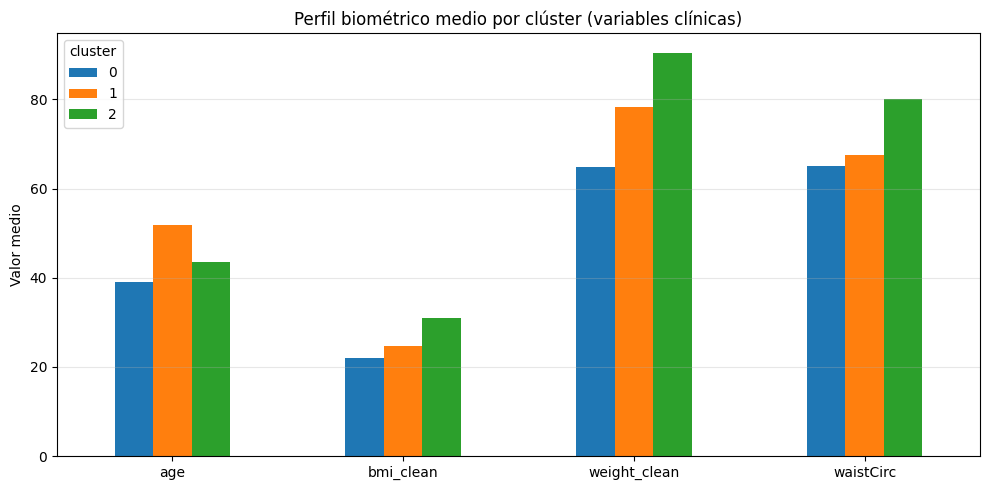

In [ ]:
vars_clinicas = ["age", "bmi_clean", "weight_clean", "waistCirc"]
vars_clinicas = [v for v in vars_clinicas if v in cluster_mean_profile.columns]

cluster_mean_profile[vars_clinicas].T.plot(kind="bar", figsize=(10, 5))
plt.title("Perfil biométrico medio por clúster (variables clínicas)")
plt.ylabel("Valor medio")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico de barras evidencia el efecto dominante del Cluster 1 en `mindfulnessTime`
(+11.207 minutos sobre la media global), lo que comprime visualmente el resto de
variables. Para las variables biométricas, las diferencias relativas más relevantes
son:

- **Cluster 0** se sitúa **por debajo** de la media en BMI (−3.12), peso (−9.04 kg)
  y circunferencia de cintura (−5.38 cm), confirmando un perfil biométrico saludable.
  Sin embargo, su actividad física (−0.11 sesiones) y mindfulness (−43 minutos)
  también quedan por debajo de la media global.

- **Cluster 2** supera la media en BMI (+5.76), peso (+16.62 kg) y cintura (+9.65 cm),
  así como en prevalencia de colesterol (+7.6 pp) y tensión arterial alta (+6.6 pp).
  Es el único cluster con desviaciones positivas consistentes en todas las variables
  de riesgo cardiometabólico.

- **Cluster 1** destaca únicamente por sus variables de engagement con la plataforma:
  +32.9 sesiones de actividad, +11.207 minutos de mindfulness y +901.065 puntos de
  gamificación. Su BMI (−0.44) es prácticamente igual a la media global, lo que
  indica que el alto compromiso no se traduce necesariamente en diferencias
  biométricas extremas respecto al resto.

## 15. Variables que más diferencian los clusters

In [ ]:

between_cluster_std = cluster_mean_profile.std(axis=0).sort_values(ascending=False)
top_diff_vars = between_cluster_std.head(20).to_frame("between_cluster_std")
display(top_diff_vars)

,between_cluster_std
gamificationPoints,522111.549747
mindfulnessTime,6489.514244
contentConsumptionMinutes,5955.353550
stepsGoal,1582.962083
foodEnergyExpenditure,588.069424
sleepGoal,56.406924
site,52.693687
physicalActivitySesions,19.042858
emotionalGoalsAchieved,13.702021
weight_clean,12.835953


La desviación típica entre centroides identifica las variables con mayor capacidad
discriminante. El ranking revela dos grupos funcionales claramente separados:

**Variables de engagement con la plataforma** encabezan la lista: `gamificationPoints`
(522.111), `mindfulnessTime` (6.489) y `contentConsumptionMinutes` (5.955) son las
que más separan los clusters, aunque su poder discriminante está concentrado en el
Cluster 1, que actúa como outlier de comportamiento.

**Variables biométricas de riesgo** aparecen a partir de la posición 10:
`weight_clean` (12.84), `waistCirc` (8.08), `age` (6.48) y `bmi_clean` (4.56) son
las que realmente diferencian el Cluster 0 del Cluster 2 y tienen mayor relevancia
clínica para la identificación de perfiles de riesgo cardiovascular.

Esta jerarquía tiene una implicación directa para el modelo: **el algoritmo separa
los clusters principalmente por comportamiento en la plataforma, y secundariamente
por riesgo biométrico**. En futuras iteraciones, podría considerarse aplicar
ponderación diferencial a las variables clínicas para reforzar la separación por
perfil de salud y no por nivel de engagement.

## 16.Interpretabilidad de clusters mediante modelos 1-vs-rest

Una vez seleccionada la solución final de clustering, necesitamos justificar **qué variables explican la pertenencia de cada usuario a cada grupo**.

Para ello se construye un modelo supervisado auxiliar bajo una estrategia **one-vs-rest**:

1. Para cada cluster se crea una variable objetivo binaria:
   - `1`: usuarios pertenecientes al cluster analizado.
   - `0`: usuarios pertenecientes al resto de clusters.

2. Se entrena un modelo de clasificación binaria para distinguir ese cluster frente a los demás.

3. Se extraen las variables más relevantes del modelo para interpretar qué factores caracterizan a cada grupo.

Es importante destacar que este paso no convierte el problema en supervisado ni implica que exista una etiqueta real de riesgo cardiovascular. El modelo se usa como herramienta de interpretabilidad post-clustering, es decir, como un **modelo surrogado** que ayuda a explicar la estructura encontrada por el algoritmo no supervisado.

En esta libreta se utiliza principalmente **Random Forest** para obtener importancias de variables, por su robustez ante relaciones no lineales, y un **árbol de decisión poco profundo** como apoyo interpretativo, ya que permite obtener reglas sencillas y defendibles.

In [ ]:
# Interpretabilidad de clusters mediante clasificación 1-vs-rest

X_explain = X_df.copy()
labels_explain = pd.Series(final_labels, index=X_df.index, name="cluster")

# Si el modelo final fuera HDBSCAN, se excluye el ruido (-1) para la interpretación de clusters.
valid_mask = labels_explain != -1
X_explain = X_explain.loc[valid_mask].reset_index(drop=True)
labels_explain = labels_explain.loc[valid_mask].reset_index(drop=True)

clusters_to_explain = sorted(labels_explain.unique())

print("Clusters a explicar:", clusters_to_explain)
print("Dimensión de X_explain:", X_explain.shape)

Clusters a explicar: [np.int32(0), np.int32(1), np.int32(2)]
Dimensión de X_explain: (4668, 452)


In [ ]:
def infer_original_variable(feature_name, original_columns, categorical_columns):
    """
    Intenta recuperar la variable original a partir del nombre transformado por el preprocesamiento.
    - Variables numéricas/binarias suelen conservar el nombre original.
    - Variables categóricas one-hot suelen aparecer como variable_categoria.
    """
    if feature_name in original_columns:
        return feature_name

    for col in categorical_columns:
        prefix = f"{col}_"
        if str(feature_name).startswith(prefix):
            return col

    return feature_name


def explain_cluster_one_vs_rest(X, labels, cluster_id, random_state=42, top_n=15):
    """
    Entrena dos modelos auxiliares para explicar un cluster frente al resto:
    - Random Forest: ranking robusto de importancia de variables.
    - Decision Tree: reglas interpretables de baja profundidad.

    Devuelve:
    - Métricas de validación hold-out.
    - Ranking de variables transformadas.
    - Ranking agregado por variable original.
    - Reglas del árbol de decisión.
    """

    y = (labels == cluster_id).astype(int)

    n_positive = int(y.sum())
    n_negative = int((1 - y).sum())

    if n_positive < 5 or n_negative < 5:
        print(f"Cluster {cluster_id}: no hay suficientes casos para entrenar un modelo 1-vs-rest.")
        return None

    stratify = y if y.nunique() == 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=random_state,
        stratify=stratify
    )

    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    metrics = {
        "cluster": cluster_id,
        "n_positive": n_positive,
        "n_negative": n_negative,
        "positive_rate": round(n_positive / len(y), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_test, y_pred), 4),
        "f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 4)
    }

    importance_df = (
        pd.DataFrame({
            "cluster": cluster_id,
            "feature": X.columns,
            "importance": rf.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["original_variable"] = importance_df["feature"].apply(
        lambda x: infer_original_variable(
            x,
            original_columns=df_model.columns.tolist(),
            categorical_columns=categorical_cols
        )
    )

    importance_by_variable = (
        importance_df
        .groupby(["cluster", "original_variable"], as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    tree = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=random_state
    )

    tree.fit(X_train, y_train)

    tree_rules = export_text(
        tree,
        feature_names=list(X.columns),
        decimals=3,
        max_depth=3
    )

    return {
        "metrics": metrics,
        "importance_df": importance_df,
        "importance_by_variable": importance_by_variable,
        "tree_rules": tree_rules
    }


cluster_explanations = {}
metrics_rows = []
importance_rows = []
importance_original_rows = []

for cluster_id in clusters_to_explain:
    explanation = explain_cluster_one_vs_rest(
        X=X_explain,
        labels=labels_explain,
        cluster_id=cluster_id,
        random_state=RANDOM_STATE,
        top_n=15
    )

    if explanation is not None:
        cluster_explanations[cluster_id] = explanation
        metrics_rows.append(explanation["metrics"])
        importance_rows.append(explanation["importance_df"])
        importance_original_rows.append(explanation["importance_by_variable"])


cluster_explain_metrics = pd.DataFrame(metrics_rows)
cluster_feature_importance = pd.concat(importance_rows, ignore_index=True)
cluster_variable_importance = pd.concat(importance_original_rows, ignore_index=True)

display(cluster_explain_metrics)

,cluster,n_positive,n_negative,positive_rate,balanced_accuracy,f1,roc_auc
0,0,3017,1651,0.6463,0.9259,0.9368,0.9842
1,1,15,4653,0.0032,1.0000,1.0000,1.0000
2,2,1636,3032,0.3505,0.9219,0.8893,0.9852


*   **Cluster 0 (64.6% de usuarios)**: Balanced Accuracy: 0.9259, F1: 0.9368, ROC-AUC: 0.9842. Cluster muy bien definido. Hay variables que separan claramente este grupo del resto. “Grupo base”

*   **Cluster 1 (0.32% de usuarios)**: solo 15 usuarios. Presenta métricas perfectas debido a su tamaño extremadamente reducido. Se trata de un grupo muy específico o atípico. Puede reflejar sobreajuste o un subconjunto de usuarios altamente diferenciados.

*   **Cluster 2 (35% de usuarios))**: Balanced Accuracy: 0.9219, F1: 0.8893
ROC-AUC: 0.9852. Muy bien separado también, perfil diferenciado claro.

Los modelos auxiliares 1-vs-rest muestran que los clusters obtenidos son altamente separables mediante variables observadas, lo que valida la calidad del clustering. Sin embargo, en clusters con muy bajo número de observaciones, las métricas pueden estar infladas debido al desbalanceo, por lo que su interpretación debe realizarse con cautela


Cluster 0 vs resto


,cluster,original_variable,importance
0,0,bmiType,0.235083
1,0,bmi_clean,0.210977
2,0,weight_clean,0.174572
3,0,waistCirc,0.104410
4,0,bodyFat,0.080832
5,0,foodEnergyExpenditure,0.047173
6,0,height_clean,0.023828
7,0,gender,0.019240
8,0,avgExerciseIntensity,0.017290
9,0,diet,0.015963


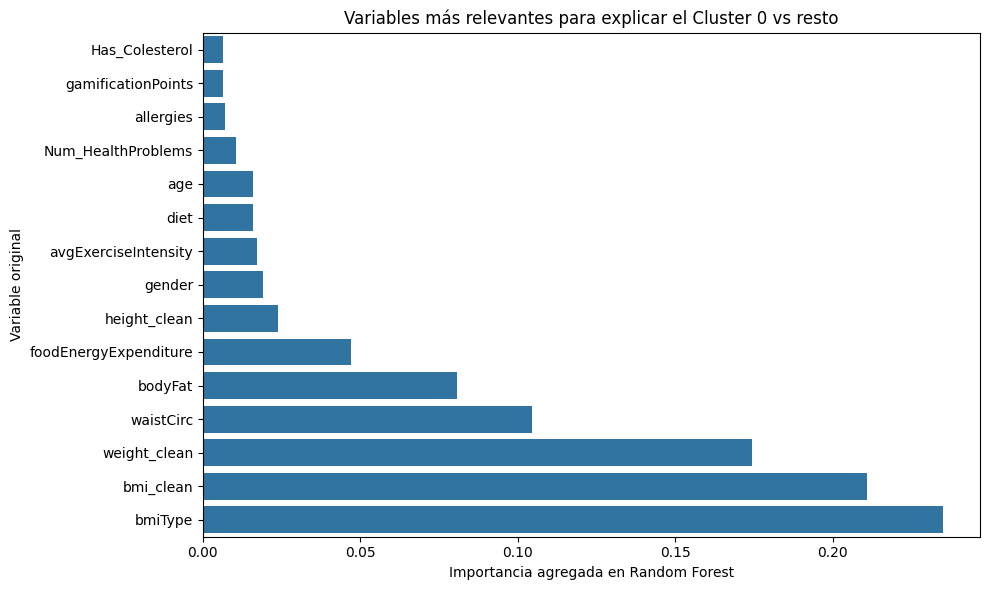

Cluster 1 vs resto


,cluster,original_variable,importance
32,1,gamificationPoints,0.127411
33,1,Has_Mindfulness,0.119864
34,1,gamificationLevels,0.086662
35,1,physicalActivitySesions,0.071384
36,1,emotionalGoalsAchieved,0.059278
37,1,age,0.048668
38,1,mindfulnessTime,0.047586
39,1,height_clean,0.041152
40,1,gender,0.039266
41,1,foodEnergyExpenditure,0.036057


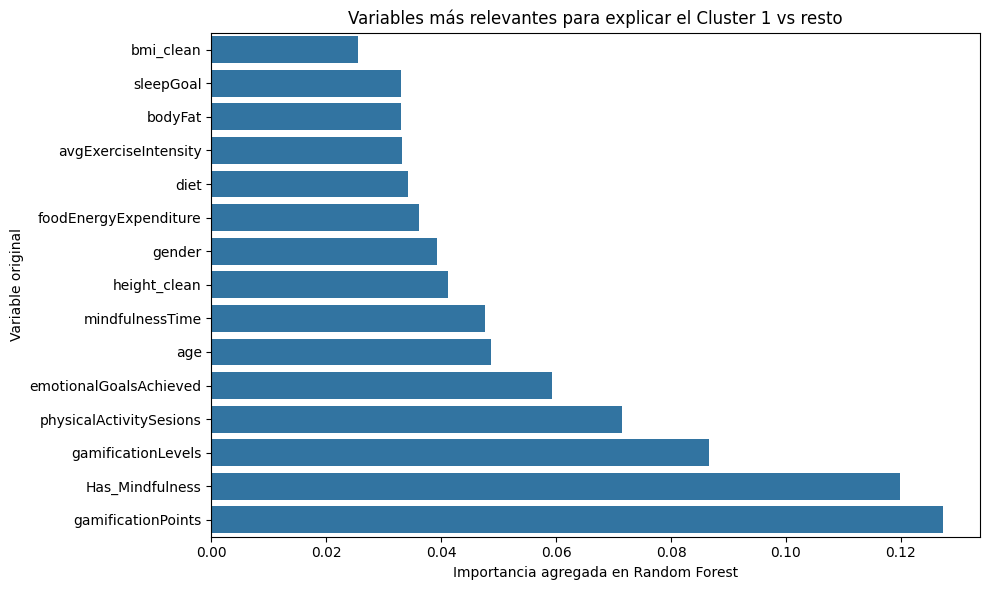

Cluster 2 vs resto


,cluster,original_variable,importance
64,2,bmiType,0.254652
65,2,bmi_clean,0.217536
66,2,weight_clean,0.170530
67,2,waistCirc,0.086159
68,2,bodyFat,0.081610
69,2,foodEnergyExpenditure,0.045011
70,2,diet,0.025176
71,2,height_clean,0.023014
72,2,age,0.018791
73,2,gender,0.014379


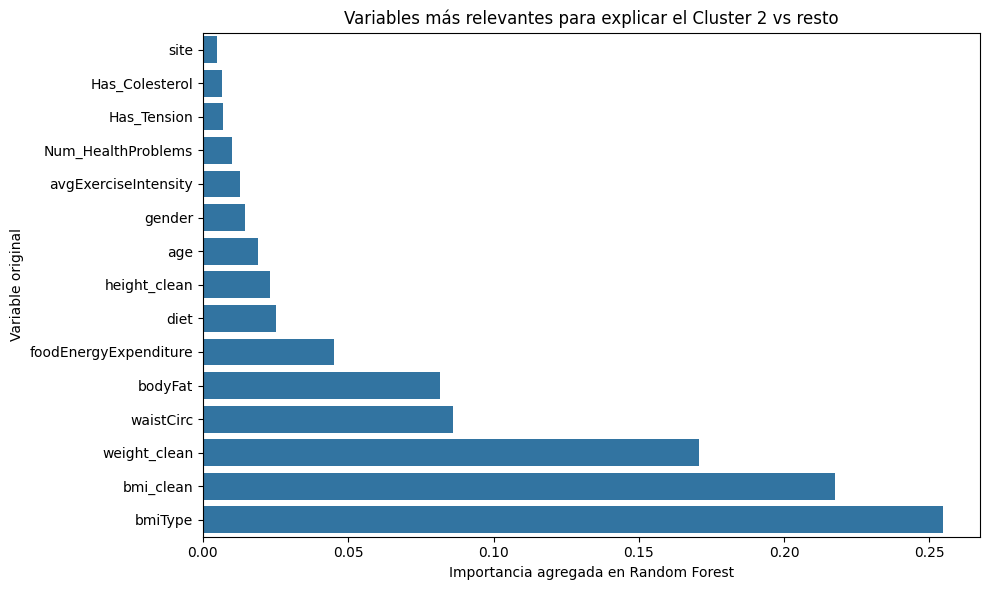

In [ ]:
# Top variables originales más relevantes para explicar cada cluster
TOP_N_VARIABLES = 15

for cluster_id in clusters_to_explain:
    print(f"Cluster {cluster_id} vs resto")

    top_vars = (
        cluster_variable_importance
        .query("cluster == @cluster_id")
        .head(TOP_N_VARIABLES)
    )

    display(top_vars)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_vars.sort_values("importance", ascending=True),
        x="importance",
        y="original_variable"
    )
    plt.title(f"Variables más relevantes para explicar el Cluster {cluster_id} vs resto")
    plt.xlabel("Importancia agregada en Random Forest")
    plt.ylabel("Variable original")
    plt.tight_layout()
    plt.show()



*   **Clusters 0**: definido por composición corporal y variables antropométricas (bmiType, bmi_clean,
weight_clean, waistCirc, bodyFat)
*   **Clusters 2**: Perfil de riesgo cardiovascular definido por variables físicas/metabólicas (bmiType, bmi_clean, weight_clean, waistCirc, bodyFat,
Has_Tension, Has_Colesterol)
*   **Cluster 1**: dominado por comportamiento digital / engagement en Wellat (gamificationPoints, Has_Mindfulness, gamificationLevels,
physicalActivitySessions, emotionalGoalsAchieved)

## TO DO: trabajar con datos originales del dataset , sin normalizar

In [ ]:
# Reglas interpretables mediante árbol de decisión poco profundo
for cluster_id, explanation in cluster_explanations.items():
    print(f"Reglas interpretables para Cluster {cluster_id} vs resto")
    print(explanation["tree_rules"])

Reglas interpretables para Cluster 0 vs resto
|--- bmi_clean <= 0.095
|   |--- waistCirc <= 1.091
|   |   |--- bmiType_overweight <= 0.500
|   |   |   |--- class: 1
|   |   |--- bmiType_overweight >  0.500
|   |   |   |--- class: 1
|   |--- waistCirc >  1.091
|   |   |--- bmi_clean <= -0.242
|   |   |   |--- class: 1
|   |   |--- bmi_clean >  -0.242
|   |   |   |--- class: 0
|--- bmi_clean >  0.095
|   |--- weight_clean <= -0.018
|   |   |--- waistCirc <= -0.009
|   |   |   |--- class: 1
|   |   |--- waistCirc >  -0.009
|   |   |   |--- class: 0
|   |--- weight_clean >  -0.018
|   |   |--- bmi_clean <= 0.451
|   |   |   |--- class: 0
|   |   |--- bmi_clean >  0.451
|   |   |   |--- class: 0

Reglas interpretables para Cluster 1 vs resto
|--- Has_Mindfulness <= 0.500
|   |--- class: 0
|--- Has_Mindfulness >  0.500
|   |--- class: 1

Reglas interpretables para Cluster 2 vs resto
|--- bmi_clean <= 0.095
|   |--- waistCirc <= 1.305
|   |   |--- bmiType_overweight <= 0.500
|   |   |   |--- 

### Interpretación metodológica de las importancias

Las variables anteriores deben interpretarse como los factores que más ayudan a **distinguir cada cluster frente al resto**, no como relaciones causales.

Por tanto:

- Si una variable aparece con alta importancia en el modelo 1-vs-rest, significa que contribuye a separar ese cluster de los demás.
- Las variables categóricas transformadas mediante one-hot encoding se agregan a su variable original para facilitar la lectura del resultado.
- El Random Forest se usa para obtener un ranking robusto de variables.
- El árbol de decisión se usa como apoyo para obtener reglas sencillas que puedan explicarse en la memoria del TFM.

Este análisis complementa el perfilado descriptivo anterior: el perfilado muestra **cómo son los clusters**, mientras que el enfoque 1-vs-rest ayuda a explicar **qué variables los diferencian mejor**.

## 17.Etiquetado interpretativo de clusters y traducción a riesgo

In [ ]:

cluster_name_map = {
    0: "Jóvenes sedentarios / Riesgo latente",
    1: "Power users / Grupo de referencia",
    2: "Riesgo metabólico / Intervención prioritaria"
}

df_profile["cluster_name"] = df_profile["cluster"].map(cluster_name_map)
display(df_profile[["cluster", "cluster_name"]].drop_duplicates().sort_values("cluster"))

### Traducción de perfiles a niveles de riesgo cardiovascular

A partir del análisis de los centroides y del perfilado descriptivo realizado en la
sección anterior, se asigna a cada cluster una etiqueta interpretativa que refleja
tanto su situación biométrica actual como su potencial de riesgo cardiovascular
a medio y largo plazo.

---

#### Cluster 0 — "Jóvenes sedentarios" · Riesgo latente (64,6 % de la plantilla)

**Perfil Intermedio en Transición:** Empleados con edad media de 39 años e indicadores biométricos dentro de la normalidad (IMC 21,98; cintura 74,6 cm). Sin embargo, presentan una actividad física prácticamente nula (mediana de 0 sesiones registradas) y un engagement mínimo con la plataforma (menos de 1 minuto de mindfulness de media).

**Nivel de riesgo:** Bajo en el presente, pero con riesgo latente a largo plazo.
La ausencia de hábitos de actividad y bienestar, combinada con el envejecimiento
natural de la plantilla, sitúa a este grupo en la trayectoria más probable hacia
el Cluster 2 si no se interviene de forma preventiva.

**Recomendaciones desde Wellat:**
- Activar campañas de gamificación orientadas a incorporar el primer hábito de
  movimiento: retos de pasos diarios, desafíos por equipos o recordatorios de
  movilidad activa durante la jornada laboral.
- Diseñar contenidos de incorporación progresiva (onboarding de bienestar) que
  reduzcan la barrera de entrada a la plataforma para usuarios con engagement cero.
- Priorizar intervenciones de bajo umbral de esfuerzo percibido: pausas activas,
  microcontenidos de mindfulness de 2-3 minutos, retos semanales con recompensas
  de gamificación.
- Promover la conexión y uso continuado de dispositivos wearables mediante
  incentivos de gamificación: bonificación de puntos por sincronización diaria
  del dispositivo, retos colectivos basados en datos de actividad registrada
  y recordatorios personalizados cuando el dispositivo lleve más de 48 horas
  sin sincronizarse. La actividad física no registrada es invisible para el
  sistema y, por tanto, no puede traducirse en intervención preventiva ni en
  reconocimiento del esfuerzo del usuario.

**Utilidad para RRHH y salud laboral:** Este segmento es el de mayor volumen y
representa la mayor oportunidad de impacto preventivo agregado. Aunque individualmente
sus indicadores no son alarmantes, la ausencia generalizada de hábitos saludables
en casi dos tercios de la plantilla supone un riesgo sistémico que puede materializarse
en incrementos de absentismo y deterioro del bienestar colectivo a medio plazo.
Los equipos de prevención deberían monitorizar la evolución anual de este grupo,
prestando especial atención a los usuarios que migren hacia perfiles biométricos
menos favorables.

---

#### Cluster 1 — "Power users" · Riesgo bajo / Grupo de referencia (0,3 % de la plantilla)

**Perfil Usuarios Activos y Altamente Comprometidos:** Grupo reducido de 15 empleados, los más veteranos de la plantilla
(edad media 51,8 años), con un compromiso excepcional con el programa de bienestar:
33 sesiones de actividad física de media, 11.251 minutos de mindfulness y 908.547
puntos de gamificación. El 100 % tiene registrado uso activo de mindfulness.
Sus indicadores biométricos son normales (IMC 24,67).

**Nivel de riesgo:** Bajo. Pese a ser el grupo de mayor edad, sus hábitos de vida
mitigan los factores de riesgo asociados al envejecimiento. El dendrograma confirma
que se separan del resto de la plantilla a una distancia de aproximadamente 80 unidades,
lo que los caracteriza como outliers de comportamiento positivo, no como casos clínicos.

**Recomendaciones desde Wellat:**
- Identificar a estos usuarios como embajadores internos del programa de bienestar:
  su perfil y trayectoria pueden utilizarse como referente motivacional para el
  resto de la plantilla.
- Diseñar programas de mentoring de hábitos saludables que aprovechen su experiencia
  y compromiso para activar al Cluster 0.
- Mantener su nivel de engagement con contenidos avanzados y retos de alto rendimiento
  que eviten la saturación del programa.

**Utilidad para RRHH y salud laboral:** Aunque representa un porcentaje marginal de
la plantilla, este grupo tiene un alto valor como prueba de concepto: demuestra que
la plataforma Wellat puede generar perfiles de bienestar sostenido incluso en los
tramos de mayor edad. Su existencia valida el potencial del programa a largo plazo
y puede utilizarse como argumento de evidencia interna ante la dirección.

---

#### Cluster 2 — "Perfil Riesgo Cardiovascular Elevado / Intervención prioritaria (35,1 % de la plantilla)

**Perfil:** Un tercio de la plantilla (1.636 usuarios, edad media 43,6 años) concentra
los indicadores biométricos de mayor riesgo cardiometabólico: IMC de 30,87 (umbral
de obesidad grado I según la OMS), circunferencia de cintura de 80,1 cm y peso
medio de 90,4 kg. La prevalencia de patologías reportadas es la más alta del dataset:
colesterol alto en el 21,2 % y tensión arterial elevada en el 13,1 % de los usuarios
del cluster. Su engagement con la plataforma es bajo, aunque ligeramente superior
al Cluster 0.

**Nivel de riesgo:** Elevado. Este segmento acumula de forma simultánea varios
factores de riesgo cardiovascular mayor —obesidad, dislipemia e hipertensión—
en una proporción significativa de sus integrantes, lo que lo convierte en el
principal objetivo de intervención preventiva del sistema.

**Recomendaciones desde Wellat:**
- Activar protocolos de intervención personalizada: asignación automática de dietas
  adaptadas (Adelgazamiento, Mediterránea, Diabetes según el perfil individual),
  con seguimiento de adherencia nutricional.
- Diseñar programas de actividad física progresiva de baja intensidad inicial,
  orientados a alcanzar el umbral de 150 minutos semanales recomendado por la OMS.
- Incorporar sesiones de mindfulness y gestión del estrés como componente del
  programa de intervención, dado el vínculo documentado entre estrés crónico y
  riesgo cardiovascular.
- Establecer alertas automáticas en la plataforma para usuarios de este cluster
  que superen umbrales críticos de IMC o circunferencia de cintura, facilitando
  la derivación a los servicios de salud laboral.

**Utilidad para RRHH y salud laboral:** Este cluster es el que genera mayor impacto
económico y sanitario para la organización. Las incapacidades temporales derivadas
de eventos cardiovasculares o patologías metabólicas crónicas tienen una duración
media superior a las bajas comunes y un coste de sustitución elevado. La identificación
temprana de este perfil permite a los equipos de prevención priorizar recursos y
diseñar intervenciones coste-eficientes antes de que los factores de riesgo
evolucionen hacia eventos clínicos de mayor gravedad.

---
### Consideración transversal: el problema del subregistro

Un elemento crítico que subyace a la interpretación de los tres perfiles es la
distinción entre **sedentarismo real y subregistro de actividad**. La mediana de
sesiones de actividad física es 0 en los Clusters 0 y 2, pero esto no implica
necesariamente que la totalidad de sus integrantes sean físicamente inactivos:
puede reflejar que no conectan su dispositivo wearable, que realizan actividad
fuera de la plataforma o que no han completado la configuración de su perfil.

Esta limitación tiene consecuencias directas sobre la calidad del modelo: si un
usuario activo no registra su actividad, el sistema le asignará un perfil de riesgo
más desfavorable del que le correspondería, y las intervenciones que se diseñen
para él estarán mal calibradas.

Por este motivo, una línea de acción prioritaria para Wellat —transversal a los
tres clusters— es **estimular la adherencia al registro** como condición previa
a la interpretación de cualquier perfil de riesgo:

- Diseñar un proceso de **onboarding estructurado** que guíe al usuario en la
  conexión del wearable y la configuración inicial de la plataforma, reduciendo
  la fricción técnica como barrera de entrada al registro.
- Establecer **incentivos de gamificación vinculados al registro continuado**,
  no solo a la actividad realizada: puntos por días consecutivos con datos
  sincronizados, logros por cobertura mensual de registro superior al 80 % de
  los días del período.
- Incorporar en los dashboards de RRHH un indicador de **cobertura de registro
  por empleado y por empresa**, que permita distinguir entre usuarios inactivos
  y usuarios con datos insuficientes para ser clasificados con fiabilidad.
- Comunicar internamente el valor del registro como acto de autocuidado: no
  solo como fuente de datos para la organización, sino como herramienta de
  seguimiento personal del propio empleado.

Mejorar la cobertura de registro aumentará directamente la calidad de los datos
de entrada al modelo en futuras iteraciones, reducirá el sesgo de subregistro en
los perfiles obtenidos y permitirá que el Cluster 0 se diferencie con mayor
precisión entre usuarios verdaderamente sedentarios y usuarios activos no
registrados.

### Síntesis: mapa de perfiles y acciones

| Cluster | Nombre | Riesgo | Acción prioritaria |
|---------|--------|--------|--------------------|
| 0 | Jóvenes sedentarios | Latente | Activar hábitos mediante gamificación y onboarding |
| 1 | Power users | Bajo | Mantener engagement y utilizar como referente |
| 2 | Riesgo metabólico | Elevado | Intervención nutricional, actividad física y seguimiento médico |

## 17. Exportación de resultados

In [ ]:

OUTPUT_DIR = Path("outputs_modeling")
OUTPUT_DIR.mkdir(exist_ok=True)

df_profile.to_csv(OUTPUT_DIR / "usuarios_con_clusters.csv", index=False)
cluster_mean_profile.to_csv(OUTPUT_DIR / "cluster_profile_mean.csv")
cluster_median_profile.to_csv(OUTPUT_DIR / "cluster_profile_median.csv")
results_all.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)

print("Archivos exportados en:", OUTPUT_DIR.resolve())
print(list(OUTPUT_DIR.iterdir()))

## 18. Conclusiones de la fase de Modelado y Evaluación

### Algoritmos comparados y proceso de selección

En esta fase se han evaluado cinco familias de algoritmos de clustering con distintas
hipótesis sobre la geometría de los grupos: K-Means, Agglomerative Clustering
(con enlaces Ward, complete y average), Gaussian Mixture Models (con cuatro tipos
de covarianza), K-Medoids y HDBSCAN. Todos los modelos han sido entrenados y
evaluados sobre el espacio completo de 452 variables resultante del pipeline de
preprocesamiento (KNN Imputer + StandardScaler para variables continuas, imputación
por moda para variables binarias, y OneHotEncoder para variables categóricas).

### Métricas de evaluación utilizadas

La evaluación cuantitativa se ha realizado con tres métricas internas complementarias:

- **Índice de Silueta**: mide la cohesión interna y la separación entre grupos.
  Valores próximos a 1 indican clusters bien definidos. Criterio de éxito: > 0,5.
- **Índice Davies-Bouldin**: mide la relación entre dispersión interna y distancia
  entre centroides. Valores más bajos son mejores. Criterio de éxito: < 1,0.
- **Índice Calinski-Harabasz**: ratio entre dispersión inter e intra-cluster.
  Valores más altos indican mejor separación global.
- **AIC/BIC en Gaussian Mixture Models**: permiten evaluar el ajuste probabilístico
  penalizando la complejidad del modelo. El BIC se utiliza como criterio especialmente
  relevante para valorar el número de componentes en GMM, aunque no se aplica a
  algoritmos no probabilísticos como K-Means o Agglomerative Clustering.

Adicionalmente, se ha analizado la **estabilidad** de la solución seleccionada
mediante el Adjusted Rand Index (ARI) y la Normalized Mutual Information (NMI)
sobre cinco semillas de inicialización distintas.

### Modelo seleccionado y justificación

**Agglomerative Clustering con enlace Ward y k=3** ha obtenido los mejores resultados
cuantitativos (silueta 0,874; Davies-Bouldin 0,346), confirmando que los datos
presentan una estructura de grupos con fronteras naturales y que los perfiles
identificados no son un artefacto del algoritmo.

**K-Means con k=3** ha sido seleccionado como modelo de producción por su
escalabilidad operativa: una vez entrenado, puede asignar un perfil a nuevos
usuarios calculando la distancia a los tres centroides, lo que permite su integración
en tiempo real en la plataforma Wellat. Su estabilidad de asignación es prácticamente
perfecta (ARI medio 0,9997 entre semillas), garantizando que un empleado no cambia
de perfil de riesgo por un simple recálculo del modelo.

La elección de k=3 frente al k=2 óptimo en métricas responde a un criterio de
diseño explícito y documentado: una segmentación binaria no permite capturar niveles
de riesgo intermedios ni diseñar intervenciones preventivas diferenciadas. Tres
perfiles son el mínimo clínicamente interpretable para dar soporte a un programa
de bienestar corporativo con distintos niveles de intensidad de intervención.

GMM y K-Medoids han quedado descartados por métricas significativamente inferiores.
HDBSCAN ha sido descartado por clasificar entre el 20 % y el 29 % de los usuarios
como ruido, lo que impediría asignar un perfil de intervención a la totalidad de
la plantilla.

### Interpretación de los clusters

Los tres perfiles obtenidos son coherentes con la distribución esperable en una
población corporativa real:

- **Cluster 0 — Jóvenes sedentarios (64,6 %)**: perfil biométrico saludable pero
  sin hábitos de actividad ni engagement con el programa de bienestar. Riesgo latente
  a largo plazo por sedentarismo.
- **Cluster 1 — Power users (0,3 %)**: outliers de comportamiento positivo con
  compromiso excepcional con la plataforma. Actúan como referente del programa y
  prueban su potencial máximo.
- **Cluster 2 — Perfil de riesgo metabólico (35,1 %)**: concentra los indicadores
  biométricos más desfavorables (IMC 30,87; cintura 80,1 cm; 21,2 % con colesterol
  alto; 13,1 % con tensión elevada). Principal objetivo de intervención preventiva.

### Implicaciones para la detección temprana de riesgo cardiovascular

Este análisis demuestra que es posible identificar perfiles de comportamiento y
riesgo diferenciados en usuarios de una plataforma de bienestar corporativo mediante
técnicas de aprendizaje no supervisado, sin necesidad de etiquetas clínicas explícitas
ni de variables de diagnóstico directo.

La segmentación obtenida tiene implicaciones concretas para la prevención:

1. Permite a los equipos de salud laboral priorizar recursos hacia el Cluster 2,
   que concentra un tercio de la plantilla con factores de riesgo cardiovascular
   acumulados.
2. Facilita el diseño de intervenciones diferenciadas por perfil, superando el
   enfoque de programas de bienestar uniformes que no tienen en cuenta la
   heterogeneidad real de la población.
3. Proporciona una base objetiva y reproducible para el seguimiento longitudinal:
   monitorizar qué usuarios migran entre clusters a lo largo del tiempo es un
   indicador directo de la efectividad del programa de prevención.


## 19. Lineas futuras de trabajo

Una de las principales líneas de mejora del presente trabajo radica en la **ampliación del conjunto de variables mediante la integración de datos procedentes de dispositivos wearables**, tales como frecuencia cardíaca, calidad del sueño o variabilidad de la frecuencia cardíaca (HRV). Estos datos permitirían enriquecer significativamente la caracterización de los usuarios, proporcionando una visión más dinámica y precisa de su estado de salud.

No obstante, la incorporación de este tipo de información implica un aumento considerable de la dimensionalidad del dataset, así como la aparición de correlaciones complejas y posibles redundancias entre variables. En este contexto, el uso de **técnicas de reducción de dimensionalidad** adquiere un papel fundamental.

Si bien en este trabajo se ha empleado Análisis de Componentes Principales (PCA) como técnica base de reducción, en escenarios con mayor complejidad y no linealidad sería recomendable explorar métodos más avanzados como **UMAP** (Uniform Manifold Approximation and Projection), que permiten preservar tanto la estructura global como local de los datos, facilitando una mejor separación de clusters en espacios de menor dimensión.

Asimismo, se podrían analizar técnicas como **t-SNE** para visualización exploratoria, aunque su aplicabilidad en procesos de clustering productivo es más limitada debido a su naturaleza no determinista.